<a href="https://colab.research.google.com/github/rantawadeesritakorn-tech/Project-Hotel/blob/main/hotel_group7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 612 104 Essential Data Science — Coding Challenge
# กลุ่มที่ 7 : โรงแรม (Hotel) — ระบบจองห้องพัก

**สมาชิกกลุ่มและส่วนที่รับผิดชอบ**

| ลำดับ | ชื่อ-สกุล | รหัสนักศึกษา | ส่วนที่รับผิดชอบ | อยู่ส่วนที่ |
|---|---|---|---|---|
| 1 | นายภูมิพัฒน์ สกุลจิตอารีย์ | 683020057-3 | ค่าคงที่ธุรกิจ, โปรไฟล์ตลาด, class Room, class Guest | 2–3 |
| 2 | นายกฤตภาส แจ่มศรี | 683020236-3 | ฟังก์ชันช่วยงาน, class Booking, การคำนวณราคา | 4 |
| 3 | นายจิรกิตติ์ พลกันธ์ | 683020565-4 | class Hotel, loop จำลองข้อมูลทีละรายการ | 5 |
| 4 | นางสาวรันตาวดี ศรีตะกร | 683020259-1 | บันทึก CSV/SQLite, อัปข้อมูลขึ้น BigQuery, SQL 7 query, วิเคราะห์ด้วย pandas, รวมงานและตรวจสอบทั้งระบบ (หัวหน้ากลุ่ม) | 6–8 |
| 5 | นายธนากร ประสงค์ดี | 683020573-5 | นำเสนอผลด้วยกราฟและ Data Storytelling, สรุปผลเชิงธุรกิจ | 9–10 |

---

## ระบบที่จำลอง

โรงแรม "Sunrise Bangkok Hotel" ขนาด 15 ห้อง (Standard 6 / Deluxe 5 / Suite 2 / Family 2)
จำลองการรับจองตั้งแต่ 1 มกราคม ถึง 30 มิถุนายน 2025

**กติกาธุรกิจที่ระบบบังคับ**
1. ห้องเดียวกันจองซ้อนช่วงวันเดียวกันไม่ได้
2. ถ้าห้องประเภทที่ขอเต็ม ระบบจะอัปเกรดห้องให้ฟรีก่อน ถ้าไม่ได้จึงปฏิเสธและบันทึกไว้
3. ราคาต่อคืน = ราคาฐาน × ตัวคูณฤดูกาล × ตัวคูณดีมานด์ (dynamic pricing)
4. ส่วนลดสมาชิก Silver 5% / Gold 10% เลื่อนขั้นอัตโนมัติเมื่อพักครบ 3 และ 6 ครั้ง
5. บวกค่าบริการ 10% แล้วบวก VAT 7%
6. ค่าคอมมิชชันช่องทาง OTA 15% / Website 2% / Walk-in และ Phone 0%
7. ใบจองที่ยกเลิกจะคืนวันว่างกลับเข้าระบบ

**ผลลัพธ์ที่ได้:** ใบจอง 960 รายการ, ลูกค้า 748 คน, อัตราการเข้าพัก 76.0%,
ADR 2,326 บาท (ตลาดกรุงเทพจริงปี 2025 อยู่ที่ 75.1% และ ADR 1,819–4,260 บาท)

## ส่วนที่ 1 — เตรียมเครื่องมือ

*ผู้รับผิดชอบ: นายภูมิพัฒน์ สกุลจิตอารีย์ (683020057-3) — ส่วนที่ 2–3*


In [41]:
import math
import os
import random
import sqlite3
from datetime import date, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
random.seed(7) # กำหนด seed เพื่อให้ผลลัพธ์ซ้ำได้ทุกครั้ง
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
os.makedirs("data", exist_ok=True)
print("พร้อมใช้งาน | pandas", pd.__version__)

พร้อมใช้งาน | pandas 2.2.3


## ส่วนที่ 2 — ค่าคงที่ธุรกิจและโปรไฟล์ตลาด

In [42]:


# --- ภาษีและค่าบริการ ---
VAT_RATE = 0.07                 # ภาษีมูลค่าเพิ่ม 7%
SERVICE_CHARGE_RATE = 0.10      # ค่าบริการโรงแรม 10%
BREAKFAST_PRICE = 350           # ค่าอาหารเช้า ต่อคืน

# --- ส่วนลดตามระดับสมาชิก ---
MEMBER_DISCOUNT = {"Regular": 0.00, "Silver": 0.05, "Gold": 0.10}
SILVER_THRESHOLD = 3            # พักครบ 3 ครั้ง -> Silver
GOLD_THRESHOLD = 6              # พักครบ 6 ครั้ง -> Gold

# --- ค่าคอมมิชชันตามช่องทางการจอง ---
CHANNEL_COMMISSION = {"Walk-in": 0.00, "Phone": 0.00, "Website": 0.02, "OTA": 0.15}

# --- ฤดูกาลท่องเที่ยว ---
HIGH_SEASON_MONTHS = [1, 2, 12]     # ราคาสูงขึ้น
LOW_SEASON_MONTHS = [5, 6, 9]       # ราคาลดลง

# --- ช่วงเวลาที่จำลอง ---
SIM_START = date(2025, 1, 1)
SIM_END = date(2025, 6, 30)

# --- ผังการอัปเกรดห้องเมื่อห้องที่ขอเต็ม ---
UPGRADE_PATH = {"Standard": "Deluxe", "Deluxe": "Suite", "Family": "Suite"}

# --- ผังห้องพักของโรงแรม (ประเภท, จำนวนห้อง, ราคา/คืน, จำนวนคนพักได้) ---
ROOM_PLAN = [
    ("Standard", 6, 1400, 2),
    ("Deluxe",   5, 2200, 2),
    ("Suite",    2, 4200, 3),
    ("Family",   2, 3000, 4),
]

RANDOM_SEED = 7                 # กลุ่มที่ 7
TARGET_BOOKINGS = 350           # เกณฑ์ขั้นต่ำของโจทย์คือ 300 รายการ

# จำนวนคำขอจองเฉลี่ยต่อวัน (ปรับค่านี้เพื่อคุมอัตราการเข้าพักให้ใกล้ความจริง)
# ตลาดกรุงเทพปี 2025 อัตราการเข้าพักเฉลี่ย ~75%
DAILY_REQUEST_RATE = 14.0
BOOKING_WINDOW_DAYS = 120       # เปิดรับจองล่วงหน้าได้สูงสุดกี่วัน

In [43]:


# โครงสร้าง: (สัดส่วนตลาด %, จำนวนคืนเฉลี่ย, จองล่วงหน้าเฉลี่ย (วัน),
#             โอกาสซื้ออาหารเช้า, น้ำหนักช่องทาง [OTA, Website, Walk-in, Phone])
MARKET_PROFILE = {
    "Thai": {
        "share": 22, "avg_nights": 1.8, "lead_time": 12, "breakfast": 0.35,
        "channel_weights": [30, 25, 25, 20],
        "first_names": ["สมชาย", "มานี", "วิชัย", "สมหญิง", "ปรีชา", "กมลวรรณ",
                        "ธนากร", "ณัฐพล", "พิมพ์ใจ", "อรวรรณ", "ศิริพร", "จิรายุ"],
        "last_names": ["ใจดี", "รักเรียน", "สายทอง", "ศรีสุข", "พงษ์พันธ์",
                       "วงศ์วิวัฒน์", "แสงจันทร์", "บุญมี", "ทองดี", "อินทรีย์"],
    },
    "Chinese": {
        "share": 18, "avg_nights": 2.6, "lead_time": 25, "breakfast": 0.55,
        "channel_weights": [70, 12, 8, 10],
        "first_names": ["Wei", "Li", "Yan", "Ming", "Hui", "Jing", "Lei", "Xiu"],
        "last_names": ["Zhang", "Wang", "Chen", "Liu", "Yang", "Huang", "Zhao"],
    },
    "Malaysian": {
        "share": 11, "avg_nights": 2.0, "lead_time": 18, "breakfast": 0.45,
        "channel_weights": [60, 18, 12, 10],
        "first_names": ["Ahmad", "Siti", "Tan", "Nurul", "Lim", "Faizal", "Mei Ling"],
        "last_names": ["Abdullah", "Ibrahim", "Wong", "Rahman", "Kumar", "Cheah"],
    },
    "Indian": {
        "share": 8, "avg_nights": 3.2, "lead_time": 30, "breakfast": 0.65,
        "channel_weights": [65, 15, 5, 15],
        "first_names": ["Rahul", "Priya", "Amit", "Neha", "Vikram", "Anjali", "Rajesh"],
        "last_names": ["Sharma", "Patel", "Singh", "Kumar", "Gupta", "Reddy"],
    },
    "Russian": {
        "share": 7, "avg_nights": 5.5, "lead_time": 45, "breakfast": 0.70,
        "channel_weights": [55, 25, 5, 15],
        "first_names": ["Ivan", "Olga", "Dmitry", "Anna", "Sergei", "Ekaterina"],
        "last_names": ["Petrov", "Ivanova", "Smirnov", "Volkov", "Kuznetsova"],
    },
    "Korean": {
        "share": 6, "avg_nights": 2.8, "lead_time": 28, "breakfast": 0.50,
        "channel_weights": [68, 17, 5, 10],
        "first_names": ["Min-jun", "Ji-woo", "Seo-yeon", "Do-hyun", "Ha-eun"],
        "last_names": ["Kim", "Lee", "Park", "Choi", "Jung", "Kang"],
    },
    "Japanese": {
        "share": 5, "avg_nights": 3.0, "lead_time": 35, "breakfast": 0.60,
        "channel_weights": [50, 25, 5, 20],
        "first_names": ["Haruto", "Yui", "Sota", "Sakura", "Ren", "Aoi"],
        "last_names": ["Sato", "Suzuki", "Takahashi", "Tanaka", "Watanabe"],
    },
    "British": {
        "share": 5, "avg_nights": 4.5, "lead_time": 48, "breakfast": 0.65,
        "channel_weights": [55, 28, 5, 12],
        "first_names": ["James", "Emma", "Oliver", "Sophie", "Harry", "Charlotte"],
        "last_names": ["Smith", "Jones", "Taylor", "Brown", "Wilson", "Davies"],
    },
    "German": {
        "share": 5, "avg_nights": 5.0, "lead_time": 50, "breakfast": 0.70,
        "channel_weights": [52, 30, 4, 14],
        "first_names": ["Lukas", "Anna", "Felix", "Lena", "Jonas", "Marie"],
        "last_names": ["Müller", "Schmidt", "Schneider", "Fischer", "Weber"],
    },
    "American": {
        "share": 5, "avg_nights": 4.0, "lead_time": 42, "breakfast": 0.60,
        "channel_weights": [55, 27, 6, 12],
        "first_names": ["Michael", "Jessica", "David", "Ashley", "Chris", "Sarah"],
        "last_names": ["Johnson", "Williams", "Miller", "Davis", "Garcia"],
    },
    "Singaporean": {
        "share": 4, "avg_nights": 2.2, "lead_time": 20, "breakfast": 0.50,
        "channel_weights": [62, 20, 8, 10],
        "first_names": ["Wei Ming", "Jia Hui", "Ryan", "Shermaine", "Daniel"],
        "last_names": ["Tan", "Lim", "Ng", "Koh", "Goh", "Teo"],
    },
    "Australian": {
        "share": 4, "avg_nights": 4.2, "lead_time": 40, "breakfast": 0.60,
        "channel_weights": [58, 26, 6, 10],
        "first_names": ["Jack", "Chloe", "Liam", "Zoe", "Ethan", "Mia"],
        "last_names": ["Anderson", "Thompson", "White", "Harris", "Martin"],
    },
}

NATIONALITIES = list(MARKET_PROFILE.keys())
NATIONALITY_WEIGHTS = [MARKET_PROFILE[n]["share"] for n in NATIONALITIES]

# ความชอบประเภทห้องต่างกันตามกลุ่มผู้เข้าพัก
# (เดินทางคนเดียว / คู่รัก / ครอบครัว / กลุ่มเพื่อน)
TRAVEL_PARTY = {
    "solo":   {"weight": 22, "adults": 1, "children": 0,
               "room_weights": {"Standard": 70, "Deluxe": 26, "Suite": 3, "Family": 1}},
    "couple": {"weight": 48, "adults": 2, "children": 0,
               "room_weights": {"Standard": 38, "Deluxe": 45, "Suite": 15, "Family": 2}},
    "family": {"weight": 22, "adults": 2, "children": 2,
               "room_weights": {"Standard": 8, "Deluxe": 20, "Suite": 17, "Family": 55}},
    "group":  {"weight": 8, "adults": 3, "children": 0,
               "room_weights": {"Standard": 30, "Deluxe": 30, "Suite": 15, "Family": 25}},
}

# อัตราการยกเลิกตามช่องทาง (Cloudbeds 2026 report: OTA 21.8% / direct 10.6%)
CANCEL_RATE_BY_CHANNEL = {
    "OTA": 0.218,
    "Website": 0.106,
    "Phone": 0.100,
    "Walk-in": 0.010,       # จ่ายเงินหน้าเคาน์เตอร์แล้ว แทบไม่ยกเลิก
}

NO_SHOW_RATE = 0.025        # ไม่มาเช็คอินโดยไม่แจ้ง ~2-3% ของใบจองที่ไม่ยกเลิก

# ตัวคูณจำนวนคนเข้าพักตามวันในสัปดาห์
# (สถิติจริง: เช็คอินวันศุกร์ 18.5% วันเสาร์ 17.2% สูงสุดของสัปดาห์)
WEEKDAY_DEMAND = {
    0: 0.80,   # จันทร์
    1: 0.80,   # อังคาร
    2: 0.85,   # พุธ
    3: 1.00,   # พฤหัสบดี
    4: 1.55,   # ศุกร์
    5: 1.45,   # เสาร์
    6: 0.95,   # อาทิตย์
}

# ตัวคูณดีมานด์รายเดือน (High season ต้นปีคนเยอะ / พ.ค.-มิ.ย. เป็น low season)
MONTH_DEMAND = {
    1: 1.25, 2: 1.20, 3: 1.05, 4: 1.00, 5: 0.85, 6: 0.80,
    7: 0.90, 8: 0.95, 9: 0.80, 10: 1.00, 11: 1.15, 12: 1.30,
}

## ส่วนที่ 3 — ออกแบบ Class : Room และ Guest

In [44]:

class Room:
    """ห้องพัก 1 ห้อง - จำ 'วันที่ถูกจองไปแล้ว' ของตัวเองไว้ในตัวเอง"""

    def __init__(self, room_id, room_number, room_type, base_price, capacity, floor):
        self.room_id = room_id
        self.room_number = room_number
        self.room_type = room_type          # Standard / Deluxe / Suite / Family
        self.base_price = base_price        # ราคาต่อคืนก่อนบวกฤดูกาล
        self.capacity = capacity
        self.floor = floor
        self.booked_dates = set()           # เก็บวันที่ถูกจองแล้ว

    def is_available(self, check_in, nights):
        """ตรวจสอบว่าห้องนี้ว่างตลอดช่วง check_in ถึง check_in+nights หรือไม่"""
        for i in range(nights):
            if (check_in + timedelta(days=i)) in self.booked_dates:
                return False                # เจอวันชนกันแม้แต่วันเดียว = จองไม่ได้
        return True

    def reserve(self, check_in, nights):
        """ยึดวันทั้งช่วงไว้ (เรียกหลังยืนยันการจองสำเร็จแล้วเท่านั้น)"""
        for i in range(nights):
            self.booked_dates.add(check_in + timedelta(days=i))

    def release(self, check_in, nights):
        """คืนวันว่างกลับเข้าระบบ - ใช้ตอนลูกค้ายกเลิกการจอง"""
        for i in range(nights):
            self.booked_dates.discard(check_in + timedelta(days=i))

    def price_per_night(self, check_in):
        """ราคาต่อคืนจริง = ราคาฐาน x ตัวคูณฤดูกาล"""
        return round(self.base_price * seasonal_multiplier(check_in), 2)

    def nights_sold(self):
        """จำนวนคืนที่ห้องนี้ขายได้ทั้งหมด"""
        return len(self.booked_dates)

    def __repr__(self):
        return f"Room({self.room_number}, {self.room_type}, {self.base_price} THB)"


def build_rooms():
    """สร้างห้องพักทั้งหมดตามผังใน config -- return list ของ Room object"""
    rooms, room_id, number = [], 1, 101
    for room_type, count, price, capacity in ROOM_PLAN:
        for _ in range(count):
            floor = number // 100
            rooms.append(Room(room_id, str(number), room_type, price, capacity, floor))
            room_id += 1
            number += 1
            if number % 100 > 10:           # ขึ้นชั้นใหม่ทุก 10 ห้อง
                number = (number // 100 + 1) * 100 + 1
    return rooms


# %% [code]
class Guest:
    """ลูกค้า 1 คน - ลูกค้าคนเดิมจองได้หลายใบ จึงต้องแยกเป็นอีกตาราง"""

    def __init__(self, guest_id, name, phone, nationality, member_tier="Regular"):
        self.guest_id = guest_id
        self.name = name
        self.phone = phone
        self.nationality = nationality
        self.member_tier = member_tier      # Regular / Silver / Gold
        self.stay_count = 0

    def discount_rate(self):
        """คืนอัตราส่วนลดตามระดับสมาชิก"""
        return MEMBER_DISCOUNT[self.member_tier]

    def upgrade_tier(self):
        """เงื่อนไขพิเศษ: พักครบตามเกณฑ์แล้วเลื่อนขั้นสมาชิกอัตโนมัติ"""
        if self.stay_count >= GOLD_THRESHOLD:
            self.member_tier = "Gold"
        elif self.stay_count >= SILVER_THRESHOLD:
            self.member_tier = "Silver"

    def record_stay(self):
        """บันทึกว่าลูกค้าคนนี้พักเพิ่มอีก 1 ครั้ง แล้วเช็คเลื่อนระดับ"""
        self.stay_count += 1
        self.upgrade_tier()

    def is_vip(self):
        """ลูกค้า VIP = ระดับ Gold ขึ้นไป"""
        return self.member_tier == "Gold"

    def __repr__(self):
        return f"Guest({self.guest_id}, {self.name}, {self.member_tier})"

## ส่วนที่ 4 — ฟังก์ชันช่วยงานและ class Booking

ฟังก์ชันทั้งหมด 15 ฟังก์ชัน มี parameter และ return
และมี default argument 10 ฟังก์ชัน

*ผู้รับผิดชอบ: นายกฤตภาส แจ่มศรี (683020236-3) — ส่วนที่ 4*


In [45]:
import random
import math

def pick_nationality():
    "สุ่มสัญชาติตามสัดส่วนตลาดจริงของนักท่องเที่ยวที่เข้าไทย"
    return random.choices(NATIONALITIES, weights=NATIONALITY_WEIGHTS, k=1)[0]

def generate_guest_name(nationality="Thai"):
    "สุ่มชื่อขนามสกุลให้ตรงกับสัญชาติ"
    p = MARKET_PROFILE[nationality]
    return f"{random.choice(p['first_names'])} {random.choice(p['last_names'])}"

def generate_phone(nationality="Thai", prefix="08"):
    "สุ่มเบอร์โทร"
    country_code = {"Chinese": "+86", "Malaysian": "+60", "Indian": "+91",
                    "Russian": "+7", "Korean": "+82", "Japanese": "+81",
                    "British": "+44", "German": "+49", "American": "+1",
                    "Singaporean": "+65", "Australian": "+61"}
    digits = "".join(str(random.randint(0, 9)) for _ in range(8))
    if nationality == "Thai":
        return prefix + digits
    return f"{country_code[nationality]}{digits}"

def pick_travel_party():
    "สุ่มลักษณะกลุ่มผู้เข้าพัก"
    kinds = list(TRAVEL_PARTY.keys())
    weights = [TRAVEL_PARTY[k]["weight"] for k in kinds]
    kind = random.choices(kinds, weights=weights, k=1)[0]
    info = TRAVEL_PARTY[kind]
    children = random.randint(1, 2) if info["children"] else 0
    return kind, info["adults"], children

def pick_room_type(party_kind="couple"):
    "สุ่มประเภทห้องตามลักษณะกลุ่มผู้เข้าพัก"
    w = TRAVEL_PARTY[party_kind]["room_weights"]
    return random.choices(list(w.keys()), weights=list(w.values()), k=1)[0]

def pick_channel(nationality="Thai", lead_time_days=0):
    "สุ่มช่องทางการจองตามพฤติกรรมของแต่ละสัญชาติ"
    channels = ["OTA", "Website", "Walk-in", "Phone"]
    weights = list(MARKET_PROFILE[nationality]["channel_weights"])
    if lead_time_days > 1:
        weights[2] = 0
    return random.choices(channels, weights=weights, k=1)[0]

def random_nights(nationality="Thai", max_nights=14):
    """สุ่มจำนวนคืนแบบ geometric รอบค่าเฉลี่ยของสัญชาตินั้น -- มี DEFAULT ARGUMENT

    การกระจายแบบนี้ทำให้ได้ผลตรงกับสถิติจริง: การจองส่วนใหญ่ (~2 ใน 3)
    เป็นการพัก 1-2 คืน แต่ยังมีหางยาวของคนที่พัก 7 คืนขึ้นไป
    """
    mean = MARKET_PROFILE[nationality]["avg_nights"]
    p = 1 / mean
    n = 1
    while random.random() > p and n < max_nights:
        n += 1
    return n

def random_lead_time(nationality="Thai", max_days=180):
    "สุ่มจำนวนวันที่จองล่วงหน้า"
    mean = MARKET_PROFILE[nationality]["lead_time"]
    days = int(random.expovariate(1 / mean))
    return min(days, max_days)

def wants_breakfast(nationality="Thai"):
    "สุ่มว่าซื้ออาหารเช้าไหม ตามพฤติกรรมของแต่ละสัญชาติ"
    return random.random() < MARKET_PROFILE[nationality]["breakfast"]

def demand_factor(check_in):
    "ตัวคูณดีมานด์ของวันนั้น"
    return MONTH_DEMAND[check_in.month] * WEEKDAY_DEMAND[check_in.weekday()]

def seasonal_multiplier(check_in, high=1.25, low=0.90):
    "ตัวคูณราคาตามฤดูกาล -- มี DEFAULT ARGUMENT (high=1.25, low=0.90)"
    if check_in.month in HIGH_SEASON_MONTHS:
        return high
    if check_in.month in LOW_SEASON_MONTHS:
        return low
    return 1.00

def dynamic_rate_multiplier(occupancy, threshold_high=0.85, threshold_mid=0.70):
    "Revenue management"
    if occupancy >= threshold_high:
        return 1.20
    if occupancy >= threshold_mid:
        return 1.10
    if occupancy < 0.40:
        return 0.92
    return 1.00

def classify_season(check_in):
    "แปลงเดือนเป็นชื่อฤดูกาลแบบข้อความ"
    if check_in.month in HIGH_SEASON_MONTHS:
        return "High"
    if check_in.month in LOW_SEASON_MONTHS:
        return "Low"
    return "Normal"

def poisson(lam):
    "สุ่มจำนวนเหตุการณ์ต่อวันแบบ Poisson"
    limit, k, p = math.exp(-lam), 0, 1.0
    while True:
        p *= random.random()
        if p <= limit:
            return k
        k += 1

def daterange(start=SIM_START, end=SIM_END):
    "วนทีละวันจาก start ถึง end"
    d = start
    while d <= end:
        yield d
        d += timedelta(days=1)


In [46]:
class Booking:
    "ใบจอง 1 ใบ - คำนวณราคาทันทีตอนสร้าง แล้วเก็บผลไว้เป็น attribute"

    def __init__(self, booking_id, guest, room, check_in, nights, channel,
                 booking_date, breakfast=False, upgraded=False,
                 adults=2, children=0, rate_multiplier=1.0):
        self.booking_id = booking_id
        self.guest = guest
        self.room = room
        self.check_in = check_in
        self.nights = nights
        self.check_out = check_in + timedelta(days=nights)
        self.channel = channel
        self.booking_date = booking_date
        self.lead_time_days = (check_in - booking_date).days
        self.breakfast = breakfast
        self.upgraded = upgraded
        self.adults = adults
        self.children = children
        self.rate_multiplier = rate_multiplier
        self.status = "CONFIRMED"
        self.cancel_date = None
        self.tier_at_booking = guest.member_tier
        self.discount_rate_used = guest.discount_rate()
        self.price_detail = self.calculate_price()

    def calculate_price(self):
        "คำนวณราคาทั้งใบ แล้ว return เป็น dict (แยกให้เห็นทุกองค์ประกอบ)"
        nightly = self.room.price_per_night(self.check_in) * self.rate_multiplier
        room_charge = round(nightly, 2) * self.nights
        extra_charge = BREAKFAST_PRICE * self.nights * self.adults if self.breakfast else 0
        subtotal = room_charge + extra_charge
        discount = subtotal * self.discount_rate_used
        net = subtotal - discount
        service_charge = net * SERVICE_CHARGE_RATE
        vat = (net + service_charge) * VAT_RATE
        total = net + service_charge + vat
        commission = total * CHANNEL_COMMISSION[self.channel]
        return {
            "rate_per_night": round(nightly, 2),
            "room_charge": round(room_charge, 2),
            "extra_charge": round(extra_charge, 2),
            "discount": round(discount, 2),
            "service_charge": round(service_charge, 2),
            "vat": round(vat, 2),
            "total_price": round(total, 2),
            "commission": round(commission, 2),
            "net_revenue": round(total - commission, 2),
        }

    def cancel(self, cancel_date=None):
        "ลูกค้ายกเลิก"
        self.status = "CANCELLED"
        self.cancel_date = cancel_date or self.booking_date
        self.room.release(self.check_in, self.nights)

    def mark_no_show(self):
        "ลูกค้าไม่มาเช็คอินโดยไม่แจ้งล่วงหน้า - โรงแรมยังเก็บเงินคืนแรกได้"
        self.status = "NO_SHOW"

    def check_out_guest(self):
        "เช็คเอาท์เรียบร้อย"
        self.status = "CHECKED_OUT"

    def is_revenue(self):
        "ใบจองนี้นับเป็นรายได้จริงไหม (ยกเลิกแล้วไม่นับ)"
        return self.status in ("CONFIRMED", "CHECKED_OUT", "NO_SHOW")

    def to_dict(self):
        "แปลง object"
        row = {
            "booking_id": self.booking_id,
            "guest_id": self.guest.guest_id,
            "room_id": self.room.room_id,
            "room_number": self.room.room_number,
            "room_type": self.room.room_type,
            "booking_date": self.booking_date.isoformat(),
            "check_in": self.check_in.isoformat(),
            "check_out": self.check_out.isoformat(),
            "nights": self.nights,
            "lead_time_days": self.lead_time_days,
            "adults": self.adults,
            "children": self.children,
            "booking_month": self.check_in.strftime("%Y-%m"),
            "weekday": self.check_in.strftime("%A"),
            "season": classify_season(self.check_in),
            "channel": self.channel,
            "nationality": self.guest.nationality,
            "breakfast": int(self.breakfast),
            "upgraded": int(self.upgraded),
            "member_tier_at_booking": self.tier_at_booking,
            "status": self.status,
            "cancel_date": self.cancel_date.isoformat() if self.cancel_date else "",
        }
        row.update(self.price_detail)
        return row

    def __repr__(self):
        return (f"Booking({self.booking_id}, {self.guest.name}, "
                f"{self.room.room_number}, {self.nights} คืน, {self.status})")

## ส่วนที่ 5 — class Hotel และการจำลองข้อมูลทีละรายการ

loop จำลองเดินตามปฏิทินทีละวัน ในแต่ละวันมีลูกค้าติดต่อเข้ามาจำนวนหนึ่ง
แล้วระบบรับจองทีละรายตามลำดับเวลา

*ผู้รับผิดชอบ: นายจิรกิตติ์ พลกันธ์ (683020565-4) — ส่วนที่ 5*


In [47]:
class Hotel:
    """ตัวโรงแรมเอง - ดูแลห้อง ลูกค้า และใบจองทั้งหมด"""

    def __init__(self, name):
        self.name = name
        self.rooms = []
        self.guests = {}                                   # dict: guest_id -> Guest
        self.bookings = []                                 # list ของ Booking ที่สำเร็จ
        self.rejected_log = []                              # เก็บรายการที่จองไม่ได้เพราะห้องเต็ม

    def add_room(self, room):
        self.rooms.append(room)

    def add_guest(self, guest):
        self.guests[guest.guest_id] = guest

    def find_available_room(self, room_type, check_in, nights):
        """หาห้องว่างประเภทที่ต้องการ - ถ้าไม่มีเลย return None"""
        candidates = [
            r for r in self.rooms
            if r.room_type == room_type
            and r.is_available(check_in, nights)
        ]

        if not candidates:
            return None
        # นโยบายโรงแรม: กระจายการใช้ห้องแบบสุ่ม ไม่ให้ห้องใดห้องหนึ่งสึกหรอเร็วเกินไป
        return random.choice(candidates)

    def occupancy_on(self, day):
        """อัตราการเข้าพักของ 'วันนั้น' -> ใช้ตัดสินใจปรับราคาแบบ dynamic pricing"""
        occupied = sum(
            1 for r in self.rooms
            if day in r.booked_dates
        )
        return occupied / len(self.rooms)

    def create_booking(
        self,
        guest,
        room_type,
        check_in,
        nights,
        channel,
        booking_date=None,
        breakfast=False,
        adults=2,
        children=0,
        rate_multiplier=1.0
    ):
        """พยายามสร้างใบจอง 1 ใบ:
        - ถ้าห้องประเภทที่ขอเต็ม -> ลองอัปเกรดให้ฟรี (เงื่อนไขพิเศษ)
        - ถ้ายังไม่ได้อีก -> ปฏิเสธ แล้วบันทึกลง rejected_log (error handling)
        """
        upgraded = False
        room = self.find_available_room(
            room_type,
            check_in,
            nights
        )

        if room is None and room_type in UPGRADE_PATH:
            room = self.find_available_room(
                UPGRADE_PATH[room_type],
                check_in,
                nights
            )
            if room is not None:
                upgraded = True

        if room is None:
            self.rejected_log.append({
                "guest_id": guest.guest_id,
                "room_type": room_type,
                "check_in": check_in.isoformat(),
                "nights": nights,
                "reason": "ห้องเต็มทุกประเภทที่รองรับได้"
            })
            return None

        booking = Booking(
            len(self.bookings) + 1,
            guest,
            room,
            check_in,
            nights,
            channel,
            booking_date or check_in,
            breakfast,
            upgraded,
            adults,
            children,
            rate_multiplier
        )

        room.reserve(check_in, nights)        # ยึดวันในปฏิทินของห้องนั้น
        guest.record_stay()                   # ลูกค้าได้แต้ม / เลื่อนระดับสมาชิก
        self.bookings.append(booking)

        return booking

    def occupancy_rate(self, start, end):
        """อัตราการเข้าพัก = คืนที่ถูกใช้จริง / คืนทั้งหมดที่ขายได้"""
        total_nights = len(self.rooms) * (
            (end - start).days + 1
        )

        sold_nights = sum(
            1
            for r in self.rooms
            for d in r.booked_dates
            if start <= d <= end
        )

        return round(
            sold_nights / total_nights * 100,
            2
        )

    def adr(self, start, end):
        """ADR (Average Daily Rate) = รายได้ค่าห้อง / จำนวนคืนที่ขายได้
        เป็นตัวชี้วัดมาตรฐานของอุตสาหกรรมโรงแรม ใช้เทียบกับตลาดจริงได้"""
        revenue = 0.0
        nights = 0

        for b in self.bookings:
            if b.is_revenue() and start <= b.check_in <= end:
                revenue += b.price_detail["room_charge"]
                nights += b.nights

        return round(
            revenue / nights,
            2
        ) if nights else 0.0

    def revpar(self, start, end):
        """RevPAR = ADR x อัตราการเข้าพัก (รายได้ต่อห้องที่มีอยู่)"""
        return round(
            self.adr(start, end)
            * self.occupancy_rate(start, end)
            / 100,
            2
        )

    def __repr__(self):
        return (
            f"Hotel({self.name}, "
            f"{len(self.rooms)} ห้อง, "
            f"{len(self.bookings)} ใบจอง)"
        )


##LOOP จำลองทีละรายการ

In [48]:
import random
from datetime import timedelta

def create_walk_in_guest(guest_id):
    """
    สร้างลูกค้าใหม่ 1 คน โดยสุ่มสัญชาติตามสัดส่วนตลาดจริงก่อน แล้วค่อยสุ่มชื่อให้ตรงชาติ

    ยังไม่บันทึกเข้าระบบทันที - จะบันทึกก็ต่อเมื่อจองสำเร็จจริง
    (คนที่โทรมาถามแล้วไม่จอง โรงแรมไม่เก็บเป็นลูกค้าในระบบ)
    """
    nat = pick_nationality()
    return Guest(
        guest_id,
        generate_guest_name(nat),
        generate_phone(nat),
        nat
    )

def run_simulation(
    hotel,
    target_bookings=None,
    repeat_rate=0.22,
    verbose=False
):
    """
    จำลองการรับจองทีละรายการตามลำดับเวลา

    target_bookings : ถ้าระบุ จะหยุดเมื่อได้ครบจำนวนนั้น (ปกติปล่อยให้เดินจนจบช่วงเวลา)
    repeat_rate     : สัดส่วนลูกค้าเก่าที่กลับมาพักซ้ำ (โรงแรมจริงราว 20-30%)
    คืนค่า dict สรุปสถิติของรอบจำลอง
    """
    next_guest_id = 1
    requests = 0

    # เปิดรับจองล่วงหน้าตั้งแต่ก่อนช่วงที่จำลองจริง เพื่อให้มีใบจองที่ lead time ยาว
    booking_start = (
        SIM_START - timedelta(days=BOOKING_WINDOW_DAYS)
    )
    # ----- เดินเวลาทีละวัน: 1 รอบของ loop นอก = 1 วันปฏิทิน -----
    for today in daterange(
        booking_start,
        SIM_END
    ):
        # จำนวนคำขอจองที่เข้ามาในวันนี้ (สุ่มแบบ Poisson ไม่เท่ากันทุกวัน)
        n_requests = poisson(
            DAILY_REQUEST_RATE
        )

        for _ in range(n_requests):
            # ----- 1 รอบของ loop ใน = ลูกค้า 1 รายติดต่อเข้ามา -----
            if (
                target_bookings
                and len(hotel.bookings) >= target_bookings
            ):
                return summarize(
                    hotel,
                    requests
                )

            requests += 1

            # 1) ลูกค้าเป็นใคร: ลูกค้าเก่ากลับมาซ้ำ หรือลูกค้าใหม่
            is_returning = (
                bool(hotel.guests)
                and random.random() < repeat_rate
            )

            if is_returning:
                guest = random.choice(
                    list(hotel.guests.values())
                )
            else:
                guest = create_walk_in_guest(
                    next_guest_id
                )

            nat = guest.nationality

            # 2) ลูกค้ารายนี้อยากได้อะไร (พฤติกรรมขึ้นกับสัญชาติและกลุ่มผู้เดินทาง)
            # โรงแรมจริงมีลูกค้า walk-in เดินเข้ามาขอห้องวันนั้นเลยอยู่ประมาณ 7%
            lead = (
                0
                if random.random() < 0.07
                else random_lead_time(nat)
            )

            check_in = (
                today + timedelta(days=lead)
            )

            if (
                check_in > SIM_END
                or check_in < SIM_START
            ):
                continue            # วันเข้าพักอยู่นอกช่วงที่เราจำลอง (ก่อน 1 ม.ค. หรือหลัง 30 มิ.ย.)

            # ถ่วงน้ำหนักตามดีมานด์จริงของวันนั้น (ศุกร์-เสาร์และ high season คนเยอะกว่า)
            if random.random() > min(
                demand_factor(check_in) / 1.9,
                1.0
            ):
                continue           # วันนั้นดีมานด์ต่ำ ลูกค้ารายนี้ไม่จอง

            party_kind, adults, children = (
                pick_travel_party()
            )

            room_type = pick_room_type(
                party_kind
            )

            nights = random_nights(nat)

            channel = pick_channel(
                nat,
                lead
            )

            breakfast = wants_breakfast(
                nat
            )
            # 3) โรงแรมตั้งราคาตามดีมานด์ ณ ตอนนั้น (revenue management)
            occ = hotel.occupancy_on(
                check_in
            )

            rate_mult = dynamic_rate_multiplier(
                occ
            )
            # 4) ส่งให้ระบบตัดสินใจว่ารับจองได้ไหม
            booking = hotel.create_booking(
                guest,
                room_type,
                check_in,
                nights,
                channel,
                booking_date=today,
                breakfast=breakfast,
                adults=adults,
                children=children,
                rate_multiplier=rate_mult
            )

            if booking is None:
                continue                               # ห้องเต็ม -> บันทึกไว้แล้วใน rejected_log

            if not is_returning:                   # จองสำเร็จแล้วค่อยขึ้นทะเบียนลูกค้าใหม่
                hotel.add_guest(guest)
                next_guest_id += 1

            if verbose:
                print(booking)

            # 5) หลังจอง: ลูกค้าอาจยกเลิกทีหลัง (อัตราขึ้นกับช่องทางที่จองมา)
            cancel_prob = (
                CANCEL_RATE_BY_CHANNEL[channel]
            )

            if lead > 30:
                cancel_prob *= 1.25            # จองล่วงหน้านาน ยิ่งมีโอกาสเปลี่ยนใจ
            elif lead <= 3:
                cancel_prob *= 0.4             # จองกระชั้น แทบไม่ยกเลิก

            if random.random() < cancel_prob:
                # ยกเลิกก่อนถึงวันเข้าพัก (เฉลี่ยแจ้งล่วงหน้าพอสมควร)
                days_before = random.randint(
                    0,
                    max(lead, 1)
                )

                booking.cancel(
                    check_in
                    - timedelta(days=days_before)
                )
            elif random.random() < NO_SHOW_RATE:
                booking.mark_no_show()                  # ไม่มาเช็คอินโดยไม่แจ้ง
            elif booking.check_out <= SIM_END:
                booking.check_out_guest()               # พักจบแล้วก่อนวันสุดท้ายที่จำลอง

    return summarize(
        hotel,
        requests
    )


def summarize(hotel, requests):
    """สรุปสถิติของรอบจำลอง -> คืนเป็น dict"""
    counts = {}

    for b in hotel.bookings:
        counts[b.status] = (
            counts.get(b.status, 0) + 1
        )

    return {
        "requests": requests,
        "bookings": len(hotel.bookings),
        "rejected": len(hotel.rejected_log),
        "guests": len(hotel.guests),
        "status_counts": counts,
        "occupancy": hotel.occupancy_rate(
            SIM_START,
            SIM_END
        ),
        "adr": hotel.adr(
            SIM_START,
            SIM_END
        ),
        "revpar": hotel.revpar(
            SIM_START,
            SIM_END
        ),
    }


## รันการจำลองระบบและเเสดงผล

In [49]:
random.seed(RANDOM_SEED)

hotel = Hotel("Bangkok Hotel")

for r in build_rooms():
    hotel.add_room(r)

print(
    f"โรงแรม '{hotel.name}' "
    f"จำนวน {len(hotel.rooms)} ห้อง"
)

stats = run_simulation(hotel)

print(f"\nคำขอจองทั้งหมด  : {stats['requests']:,} ราย")
print(f"จองสำเร็จ        : {stats['bookings']:,} ใบ")
print(f"ถูกปฏิเสธ        : {stats['rejected']:,} ราย (ห้องเต็ม)")
print(f"ลูกค้าในระบบ     : {stats['guests']:,} คน")
print(f"สถานะใบจอง      : {stats['status_counts']}")
print(f"\nOccupancy : {stats['occupancy']:.1f} %")
print(f"ADR       : {stats['adr']:,.0f} บาท")
print(f"RevPAR    : {stats['revpar']:,.0f} บาท")


โรงแรม 'Bangkok Hotel' จำนวน 15 ห้อง

คำขอจองทั้งหมด  : 4,177 ราย
จองสำเร็จ        : 960 ใบ
ถูกปฏิเสธ        : 451 ราย (ห้องเต็ม)
ลูกค้าในระบบ     : 748 คน
สถานะใบจอง      : {'CHECKED_OUT': 777, 'CANCELLED': 156, 'NO_SHOW': 16, 'CONFIRMED': 11}

Occupancy : 76.0 %
ADR       : 2,326 บาท
RevPAR    : 1,768 บาท


In [50]:
# ตัวอย่างใบจองและรายการที่ถูกปฏิเสธ
for b in hotel.bookings[:5]:
    print(b)
print("\nตัวอย่างรายการที่จองไว้ไม่ได้:")
for r in hotel.rejected_log[:3]:
    print(" ", r)


Booking(1, Haruto Suzuki, 105, 1 คืน, CHECKED_OUT)
Booking(2, Mia White, 110, 1 คืน, CANCELLED)
Booking(3, Mia White, 203, 8 คืน, CHECKED_OUT)
Booking(4, Anna Fischer, 101, 6 คืน, CHECKED_OUT)
Booking(5, Marie Müller, 106, 12 คืน, CHECKED_OUT)

ตัวอย่างรายการที่จองไว้ไม่ได้:
  {'guest_id': 23, 'room_type': 'Suite', 'check_in': '2025-01-25', 'nights': 4, 'reason': 'ห้องเต็มทุกประเภทที่รองรับได้'}
  {'guest_id': 19, 'room_type': 'Suite', 'check_in': '2025-01-21', 'nights': 4, 'reason': 'ห้องเต็มทุกประเภทที่รองรับได้'}
  {'guest_id': 41, 'room_type': 'Deluxe', 'check_in': '2025-01-07', 'nights': 14, 'reason': 'ห้องเต็มทุกประเภทที่รองรับได้'}


## ส่วนที่ 6 — บันทึกข้อมูลลง CSV และ SQLite

ออกแบบเป็น 3 ตารางที่สัมพันธ์กัน: `guests` และ `rooms` เชื่อมกันผ่าน `bookings`

*ผู้รับผิดชอบ: นางสาวรันตาวดี ศรีตะกร (683020259-1) — ส่วนที่ 6–8 (หัวหน้ากลุ่ม)*


In [51]:
def export_dataframes(hotel):
    """แปลง object ทั้งหมดเป็น DataFrame 3 ตัว (guests / rooms / bookings)"""
    guests_df = pd.DataFrame([{
        "guest_id": g.guest_id,
        "name": g.name,
        "phone": g.phone,
        "nationality": g.nationality,
        "member_tier": g.member_tier,
        "stay_count": g.stay_count,
    } for g in hotel.guests.values()])

    rooms_df = pd.DataFrame([{
        "room_id": r.room_id,
        "room_number": r.room_number,
        "room_type": r.room_type,
        "base_price": r.base_price,
        "capacity": r.capacity,
        "floor": r.floor,
        "nights_sold": r.nights_sold(),
    } for r in hotel.rooms])

    # list comprehension เรียก method to_dict() ของ object แต่ละใบ
    bookings_df = pd.DataFrame([b.to_dict() for b in hotel.bookings])
    return guests_df, rooms_df, bookings_df


def save_csv(guests_df, rooms_df, bookings_df, folder="data"):
    """บันทึก CSV 3 ไฟล์ลงโฟลเดอร์ data/"""
    os.makedirs(folder, exist_ok=True)
    paths = {}
    for name, df in [("hotel_guests", guests_df), ("hotel_rooms", rooms_df),
                     ("hotel_bookings", bookings_df)]:
        path = os.path.join(folder, f"{name}.csv")
        df.to_csv(path, index=False, encoding="utf-8-sig")
        paths[name] = path
    return paths


def save_sqlite(guests_df, rooms_df, bookings_df, db_path="data/hotel.db"):
    """สร้างฐานข้อมูล SQLite 3 ตาราง แล้ว return connection"""
    os.makedirs(os.path.dirname(db_path), exist_ok=True)
    conn = sqlite3.connect(db_path)
    guests_df.to_sql("guests", conn, if_exists="replace", index=False)
    rooms_df.to_sql("rooms", conn, if_exists="replace", index=False)
    bookings_df.to_sql("bookings", conn, if_exists="replace", index=False)
    conn.commit()
    return conn

In [52]:
guests_df, rooms_df, bookings_df = export_dataframes(hotel)
paths = save_csv(guests_df, rooms_df, bookings_df)
conn = save_sqlite(guests_df, rooms_df, bookings_df)

print("บันทึกไฟล์เรียบร้อย")
for p in paths.values():
    print("  ", p)
print("   data/hotel.db")
print("\nขนาดตาราง | bookings:", bookings_df.shape,
      "| guests:", guests_df.shape, "| rooms:", rooms_df.shape)
bookings_df.head()

บันทึกไฟล์เรียบร้อย
   data/hotel_guests.csv
   data/hotel_rooms.csv
   data/hotel_bookings.csv
   data/hotel.db

ขนาดตาราง | bookings: (960, 31) | guests: (748, 6) | rooms: (15, 7)


,booking_id,guest_id,room_id,room_number,room_type,booking_date,check_in,check_out,nights,lead_time_days,...,cancel_date,rate_per_night,room_charge,extra_charge,discount,service_charge,vat,total_price,commission,net_revenue
0,1,1,5,105,Standard,2024-09-07,2025-01-31,2025-02-01,1,146,...,,"1,610.00","1,610.00",0,0.00,161.00,123.97,"1,894.97",284.25,"1,610.72"
1,2,2,10,110,Deluxe,2024-09-08,2025-03-07,2025-03-08,1,180,...,2025-02-12,"2,024.00","2,024.00",0,0.00,202.40,155.85,"2,382.25",357.34,"2,024.91"
2,3,2,13,203,Suite,2024-09-16,2025-01-18,2025-01-26,8,124,...,,"4,830.00","38,640.00",8400,0.00,"4,704.00","3,622.08","55,366.08","8,304.91","47,061.17"
3,4,3,1,101,Standard,2024-09-20,2025-01-10,2025-01-16,6,112,...,,"1,610.00","9,660.00",2100,0.00,"1,176.00",905.52,"13,841.52",276.83,"13,564.69"
4,5,4,6,106,Standard,2024-09-20,2025-01-02,2025-01-14,12,104,...,,"1,610.00","19,320.00",4200,0.00,"2,352.00","1,811.04","27,683.04","4,152.46","23,530.58"


## ส่วนที่ 7 — วิเคราะห์ด้วย SQL

**Query ที่เขียนทั้งหมด 7 query**
- Query 1–3 : SELECT / WHERE / ORDER BY
- Query 4 : GROUP BY + aggregate function (COUNT / SUM / AVG)
- Query 5–6 : JOIN (Query 5 เป็นการ JOIN 3 ตารางพร้อมกัน)
- Query 7 : CASE WHEN + GROUP BY

รันผ่านฐานข้อมูล SQLite (`data/hotel.db`) ด้วย `pandas.read_sql_query()` แสดงผลทุก query เป็น DataFrame


In [53]:
# ตัวรัน SQL หลักของงานนี้ : อ่านจากฐานข้อมูล SQLite (data/hotel.db) ที่สร้างไว้ในส่วนที่ 6
# ใช้ pandas.read_sql_query() แสดงผลลัพธ์ของทุก query เป็น DataFrame

def q(sql):
    """รัน SQL บนฐานข้อมูล SQLite แล้วคืนผลลัพธ์เป็น DataFrame

    {t} และ {e} เป็นตัวคั่นชื่อตาราง ทำให้ query ชุดเดียวกันนำไปรันบน
    BigQuery ได้ด้วยโดยไม่ต้องแก้ (ดูส่วนเสริมท้ายหัวข้อนี้)
    """
    full = sql.replace("{t}", "").replace("{e}", "")
    return pd.read_sql_query(full, conn)


# ตรวจว่าตารางในฐานข้อมูลครบ 3 ตารางก่อนเริ่ม query
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
)
print("ตารางในฐานข้อมูล data/hotel.db :", ", ".join(tables["name"]))
for t in tables["name"]:
    n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
    print(f"   {t:10s} {n:,} แถว")


ตารางในฐานข้อมูล data/hotel.db : bookings, guests, rooms
   bookings   960 แถว
   guests     748 แถว
   rooms      15 แถว


**Query 1** — SELECT / WHERE / ORDER BY : ใบจองห้อง Suite ที่ยอดสูงสุด 10 อันดับแรก

In [54]:
q1 = q("""
    SELECT booking_id, room_number, check_in, nights, channel,
           ROUND(total_price, 2) AS total_price
    FROM {t}bookings{e}
    WHERE room_type = 'Suite' AND status != 'CANCELLED'
    ORDER BY total_price DESC
    LIMIT 10
""")
q1

,booking_id,room_number,check_in,nights,channel,total_price
0,93,202,2025-01-29,12,OTA,"78,105.72"
1,465,203,2025-03-23,11,OTA,"63,440.30"
2,358,203,2025-02-27,9,OTA,"63,028.35"
3,3,203,2025-01-18,8,OTA,"55,366.08"
4,406,202,2025-02-28,8,Website,"49,434.00"
5,100,203,2025-02-01,7,Website,"49,022.05"
6,451,203,2025-04-28,10,OTA,"45,479.28"
7,281,202,2025-02-15,5,Phone,"38,105.38"
8,9,203,2025-01-11,6,OTA,"34,109.46"
9,147,202,2025-03-09,6,OTA,"32,230.97"


**Query 2** — SELECT / WHERE / ORDER BY : ผู้เข้าพักที่จองล่วงหน้านานที่สุดในช่วง High season

In [55]:
q2 = q("""
    SELECT booking_id, nationality, room_type, check_in,
           lead_time_days, nights, ROUND(total_price, 2) AS total_price
    FROM {t}bookings{e}
    WHERE season = 'High' AND lead_time_days >= 60 AND status != 'CANCELLED'
    ORDER BY lead_time_days DESC
    LIMIT 15
""")
q2

,booking_id,nationality,room_type,check_in,lead_time_days,nights,total_price
0,1,Japanese,Standard,2025-01-31,146,1,"1,894.97"
1,8,German,Standard,2025-02-17,140,14,"38,064.18"
2,3,Australian,Suite,2025-01-18,124,8,"55,366.08"
3,10,Thai,Standard,2025-01-31,121,3,"8,156.61"
4,26,Russian,Standard,2025-02-23,121,4,"7,579.88"
5,4,German,Standard,2025-01-10,112,6,"13,841.52"
6,12,German,Standard,2025-01-25,110,6,"13,841.52"
7,44,Korean,Family,2025-02-28,110,1,"4,884.55"
8,23,Indian,Standard,2025-02-05,108,3,"5,684.91"
9,25,Japanese,Standard,2025-02-08,108,4,"7,579.88"


**Query 3** — SELECT / WHERE / ORDER BY : ใบจองที่ถูกยกเลิกและมูลค่าที่เสียโอกาส

In [56]:
q3 = q("""
    SELECT booking_id, room_type, channel, check_in, nights, lead_time_days,
           ROUND(total_price, 2) AS lost_revenue
    FROM {t}bookings{e}
    WHERE status = 'CANCELLED'
    ORDER BY total_price DESC
    LIMIT 20
""")
q3

,booking_id,room_type,channel,check_in,nights,lead_time_days,lost_revenue
0,672,Suite,Website,2025-05-25,10,49,"49,170.35"
1,14,Suite,Website,2025-01-16,8,95,"48,774.88"
2,893,Suite,OTA,2025-06-21,8,22,"42,183.68"
3,126,Standard,OTA,2025-02-14,14,58,"38,064.18"
4,877,Standard,OTA,2025-06-15,14,19,"36,403.20"
5,77,Standard,OTA,2025-01-24,10,55,"32,956.00"
6,116,Standard,OTA,2025-03-27,14,102,"32,758.26"
7,848,Standard,Phone,2025-06-05,14,15,"32,296.88"
8,57,Deluxe,Website,2025-01-24,7,67,"29,495.62"
9,139,Family,OTA,2025-01-12,6,22,"29,130.75"


**Query 4** — GROUP BY + aggregate function (COUNT / SUM / AVG)

In [57]:
q4 = q("""
    SELECT room_type,
           COUNT(*)                   AS total_bookings,
           SUM(nights)                AS total_nights,
           ROUND(AVG(nights), 2)      AS avg_nights,
           ROUND(SUM(total_price), 2) AS total_revenue,
           ROUND(AVG(total_price), 2) AS avg_per_booking,
           ROUND(SUM(net_revenue) / SUM(nights), 2) AS net_revenue_per_night
    FROM {t}bookings{e}
    WHERE status != 'CANCELLED'
    GROUP BY room_type
    ORDER BY total_revenue DESC
""")
q4

,room_type,total_bookings,total_nights,avg_nights,total_revenue,avg_per_booking,net_revenue_per_night
0,Deluxe,275,722,2.63,"2,233,591.55","8,122.15","2,830.08"
1,Standard,315,833,2.64,"1,746,236.45","5,543.61","1,908.47"
2,Suite,110,280,2.55,"1,589,850.43","14,453.19","5,112.86"
3,Family,104,252,2.42,"1,026,769.50","9,872.78","3,683.70"


**Query 5** — JOIN 3 ตารางพร้อมกัน : ลูกค้าสัญชาติใดจ่ายให้ห้องประเภทใดมากที่สุด

In [58]:
q5 = q("""
    SELECT g.nationality,
           r.room_type,
           COUNT(b.booking_id)             AS bookings,
           ROUND(SUM(b.total_price), 2)    AS revenue,
           ROUND(AVG(b.nights), 2)         AS avg_nights,
           ROUND(AVG(b.lead_time_days), 1) AS avg_lead_time
    FROM {t}bookings{e} AS b
    JOIN {t}guests{e}   AS g ON b.guest_id = g.guest_id
    JOIN {t}rooms{e}    AS r ON b.room_id  = r.room_id
    WHERE b.status != 'CANCELLED'
    GROUP BY g.nationality, r.room_type
    HAVING bookings >= 5
    ORDER BY revenue DESC
    LIMIT 15
""")
q5

,nationality,room_type,bookings,revenue,avg_nights,avg_lead_time
0,German,Standard,23,"306,223.04",6.39,58.10
1,Chinese,Deluxe,44,"303,916.92",2.23,22.70
2,Russian,Deluxe,21,"276,750.46",4.14,49.80
3,German,Deluxe,19,"273,817.20",4.63,76.20
4,Chinese,Suite,21,"272,995.99",2.19,23.80
5,Thai,Deluxe,65,"268,392.97",1.37,11.20
6,British,Deluxe,14,"265,064.88",5.57,62.10
7,Chinese,Standard,52,"242,163.15",2.17,20.80
8,Russian,Standard,26,"220,549.79",4.00,57.80
9,Thai,Standard,67,"214,266.71",1.57,12.60


**Query 6** — JOIN + GROUP BY : ลูกค้า 5 อันดับแรกที่ใช้จ่ายมากที่สุด

In [59]:
q6 = q("""
    SELECT g.name, g.nationality, g.member_tier,
           COUNT(b.booking_id)          AS times_stayed,
           SUM(b.nights)                AS total_nights,
           ROUND(SUM(b.total_price), 2) AS total_spend
    FROM {t}guests{e}   AS g
    JOIN {t}bookings{e} AS b ON g.guest_id = b.guest_id
    WHERE b.status != 'CANCELLED'
    GROUP BY g.guest_id, g.name, g.nationality, g.member_tier
    ORDER BY total_spend DESC
    LIMIT 5
""")
q6

,name,nationality,member_tier,times_stayed,total_nights,total_spend
0,Anna Fischer,German,Gold,7,46,"129,313.12"
1,Jessica Miller,American,Gold,5,31,"105,595.44"
2,Sarah Williams,American,Silver,3,22,"88,174.96"
3,James Davies,British,Regular,2,21,"83,625.85"
4,Rahul Gupta,Indian,Regular,1,12,"78,105.72"


**Query 7** — CASE WHEN + GROUP BY : อัตราการยกเลิกและค่าคอมมิชชันแยกตามช่องทาง

In [60]:
q7 = q("""
    SELECT channel,
           COUNT(*) AS total_bookings,
           SUM(CASE WHEN status = 'CANCELLED' THEN 1 ELSE 0 END) AS cancelled,
           ROUND(100 * SUM(CASE WHEN status = 'CANCELLED' THEN 1 ELSE 0 END)
                 / COUNT(*), 1) AS cancel_rate_pct,
           ROUND(SUM(commission), 0) AS commission_paid
    FROM {t}bookings{e}
    GROUP BY channel
    ORDER BY cancel_rate_pct DESC
""")
q7

,channel,total_bookings,cancelled,cancel_rate_pct,commission_paid
0,OTA,553,118,21.00,"702,930.00"
1,Website,237,23,9.00,"38,353.00"
2,Phone,163,15,9.00,0.00
3,Walk-in,7,0,0.00,0.00


## ส่วนที่ 8 — วิเคราะห์ด้วย pandas

**คำถามทางธุรกิจที่กลุ่มตั้งไว้**
1. ห้องประเภทใดทำรายได้สุทธิมากที่สุด และคุ้มที่สุดเมื่อคิดต่อคืน
2. ช่องทางการจองใดทำเงินได้จริงมากที่สุดหลังหักค่าคอมมิชชัน
3. ฤดูกาลมีผลต่อราคาและปริมาณการจองอย่างไร
4. ลูกค้ากลุ่มใดใช้จ่ายมากที่สุด

*ผู้รับผิดชอบ: นางสาวรันตาวดี ศรีตะกร (683020259-1) — ส่วนที่ 6–8 (หัวหน้ากลุ่ม)*


In [61]:
bookings = pd.read_csv("data/hotel_bookings.csv")
guests = pd.read_csv("data/hotel_guests.csv")
rooms = pd.read_csv("data/hotel_rooms.csv")

bookings["check_in"] = pd.to_datetime(bookings["check_in"])
bookings["booking_date"] = pd.to_datetime(bookings["booking_date"])

print("bookings:", bookings.shape, "| guests:", guests.shape, "| rooms:", rooms.shape)
bookings.head()

bookings: (960, 31) | guests: (748, 6) | rooms: (15, 7)


,booking_id,guest_id,room_id,room_number,room_type,booking_date,check_in,check_out,nights,lead_time_days,...,cancel_date,rate_per_night,room_charge,extra_charge,discount,service_charge,vat,total_price,commission,net_revenue
0,1,1,5,105,Standard,2024-09-07,2025-01-31,2025-02-01,1,146,...,NaN,"1,610.00","1,610.00",0,0.00,161.00,123.97,"1,894.97",284.25,"1,610.72"
1,2,2,10,110,Deluxe,2024-09-08,2025-03-07,2025-03-08,1,180,...,2025-02-12,"2,024.00","2,024.00",0,0.00,202.40,155.85,"2,382.25",357.34,"2,024.91"
2,3,2,13,203,Suite,2024-09-16,2025-01-18,2025-01-26,8,124,...,NaN,"4,830.00","38,640.00",8400,0.00,"4,704.00","3,622.08","55,366.08","8,304.91","47,061.17"
3,4,3,1,101,Standard,2024-09-20,2025-01-10,2025-01-16,6,112,...,NaN,"1,610.00","9,660.00",2100,0.00,"1,176.00",905.52,"13,841.52",276.83,"13,564.69"
4,5,4,6,106,Standard,2024-09-20,2025-01-02,2025-01-14,12,104,...,NaN,"1,610.00","19,320.00",4200,0.00,"2,352.00","1,811.04","27,683.04","4,152.46","23,530.58"


In [62]:
bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   booking_id              960 non-null    int64         
 1   guest_id                960 non-null    int64         
 2   room_id                 960 non-null    int64         
 3   room_number             960 non-null    int64         
 4   room_type               960 non-null    object        
 5   booking_date            960 non-null    datetime64[ns]
 6   check_in                960 non-null    datetime64[ns]
 7   check_out               960 non-null    object        
 8   nights                  960 non-null    int64         
 9   lead_time_days          960 non-null    int64         
 10  adults                  960 non-null    int64         
 11  children                960 non-null    int64         
 12  booking_month           960 non-null    object    

In [63]:
bookings[["nights", "lead_time_days", "rate_per_night",
          "total_price", "commission", "net_revenue"]].describe()

,nights,lead_time_days,rate_per_night,total_price,commission,net_revenue
count,960.00,960.00,960.00,960.00,960.00,960.00
mean,2.61,31.43,"2,350.05","8,215.77",772.17,"7,443.60"
std,2.54,33.62,"1,042.79","9,084.04","1,226.08","8,208.86"
min,1.00,0.00,"1,159.20","1,296.16",0.00,"1,159.72"
25%,1.00,8.00,"1,540.00","3,024.30",64.73,"2,749.03"
50%,2.00,21.00,"2,024.00","5,178.80",369.51,"4,661.51"
75%,3.00,41.25,"2,760.00","9,618.44",946.31,"8,753.32"
max,14.00,180.00,"6,300.00","78,105.72","11,715.86","66,389.86"


ตัดใบจองที่ยกเลิกออกก่อนวิเคราะห์รายได้ เนื่องจากไม่ได้สร้างรายได้จริง



In [64]:
active = bookings[bookings["status"] != "CANCELLED"].copy()
cancel_rate = (bookings["status"] == "CANCELLED").mean() * 100

print(f"ใบจองทั้งหมด {len(bookings):,} ใบ | ใช้วิเคราะห์รายได้ {len(active):,} ใบ")
print(f"อัตราการยกเลิก {cancel_rate:.2f}%")
print(bookings["status"].value_counts())

ใบจองทั้งหมด 960 ใบ | ใช้วิเคราะห์รายได้ 804 ใบ
อัตราการยกเลิก 16.25%
status
CHECKED_OUT    777
CANCELLED      156
NO_SHOW         16
CONFIRMED       11
Name: count, dtype: int64


### คำถามที่ 1 : รายได้แยกตามประเภทห้อง (groupby + agg + sort_values)

In [65]:
by_room_type = active.groupby("room_type").agg(
    total_bookings=("booking_id", "count"),
    total_nights=("nights", "sum"),
    avg_nights=("nights", "mean"),
    avg_rate=("rate_per_night", "mean"),
    total_revenue=("total_price", "sum"),
    net_revenue=("net_revenue", "sum"),
).reset_index()

by_room_type["net_per_night"] = by_room_type["net_revenue"] / by_room_type["total_nights"]
by_room_type = by_room_type.sort_values("net_revenue", ascending=False)
by_room_type

,room_type,total_bookings,total_nights,avg_nights,avg_rate,total_revenue,net_revenue,net_per_night
0,Deluxe,275,722,2.63,"2,311.80","2,233,591.55","2,043,321.05","2,830.08"
2,Standard,315,833,2.64,"1,475.93","1,746,236.45","1,589,757.85","1,908.47"
3,Suite,110,280,2.55,"4,354.56","1,589,850.43","1,431,600.85","5,112.86"
1,Family,104,252,2.42,"3,113.45","1,026,769.50","928,291.54","3,683.70"


### คำถามที่ 2 : ช่องทางการจอง

In [66]:
by_channel = active.groupby("channel").agg(
    bookings=("booking_id", "count"),
    gross_revenue=("total_price", "sum"),
    commission_paid=("commission", "sum"),
    net_revenue=("net_revenue", "sum"),
    avg_lead_time=("lead_time_days", "mean"),
).reset_index()
by_channel["commission_pct"] = (by_channel["commission_paid"]
                                / by_channel["gross_revenue"] * 100)
by_channel.sort_values("net_revenue", ascending=False)

,channel,bookings,gross_revenue,commission_paid,net_revenue,avg_lead_time,commission_pct
0,OTA,435,"3,803,046.63","570,456.98","3,232,589.69",31.56,15.00
3,Website,214,"1,650,983.50","33,019.73","1,617,963.80",30.51,2.00
1,Phone,148,"1,099,263.10",0.00,"1,099,263.10",28.53,0.00
2,Walk-in,7,"43,154.70",0.00,"43,154.70",0.00,0.00


### คำถามที่ 3 : ฤดูกาลและรายเดือน

In [67]:
by_season = active.groupby("season").agg(
    bookings=("booking_id", "count"),
    total_nights=("nights", "sum"),
    avg_rate=("rate_per_night", "mean"),
    revenue=("total_price", "sum"),
).reset_index().sort_values("avg_rate", ascending=False)

by_month = active.groupby("booking_month").agg(
    bookings=("booking_id", "count"),
    room_nights=("nights", "sum"),
    avg_rate=("rate_per_night", "mean"),
    revenue=("total_price", "sum"),
).reset_index().sort_values("booking_month")
by_month["occupancy_%"] = by_month["room_nights"] / (len(rooms) * 30) * 100

display(by_season)
by_month

,season,bookings,total_nights,avg_rate,revenue
0,High,276,753,"2,845.63","2,809,343.92"
2,Normal,270,701,"2,228.65","2,094,781.58"
1,Low,258,633,"2,001.29","1,692,322.43"


,booking_month,bookings,room_nights,avg_rate,revenue,occupancy_%
0,2025-01,140,411,"2,893.39","1,549,074.73",91.33
1,2025-02,136,342,"2,796.47","1,260,269.19",76.00
2,2025-03,134,344,"2,176.36","1,014,034.96",76.44
3,2025-04,136,357,"2,280.18","1,080,746.62",79.33
4,2025-05,137,341,"2,007.93","896,624.44",75.78
5,2025-06,121,292,"1,993.78","795,697.99",64.89


### คำถามที่ 4 : ลูกค้าและตลาดที่ใช้จ่ายมากที่สุด (sort_values)

In [68]:
spend = active.groupby("guest_id").agg(
    total_spend=("total_price", "sum"),
    times_stayed=("booking_id", "count"),
    total_nights=("nights", "sum"),
).reset_index()

top_guests = (spend.merge(guests[["guest_id", "name", "nationality", "member_tier"]],
                          on="guest_id")
              .sort_values("total_spend", ascending=False).head(5))
display(top_guests)

by_nat = active.groupby("nationality").agg(
    bookings=("booking_id", "count"),
    revenue=("total_price", "sum"),
    avg_spend=("total_price", "mean"),
    avg_nights=("nights", "mean"),
    avg_lead_time=("lead_time_days", "mean"),
).reset_index().sort_values("revenue", ascending=False)
by_nat

,guest_id,total_spend,times_stayed,total_nights,name,nationality,member_tier
2,3,"129,313.12",7,46,Anna Fischer,German,Gold
4,5,"105,595.44",5,31,Jessica Miller,American,Gold
34,37,"88,174.96",3,22,Sarah Williams,American,Silver
68,75,"83,625.85",2,21,James Davies,British,Regular
49,53,"78,105.72",1,12,Rahul Gupta,Indian,Regular


,nationality,bookings,revenue,avg_spend,avg_nights,avg_lead_time
3,Chinese,127,"900,359.68","7,089.45",2.17,22.74
11,Thai,191,"882,907.27","4,622.55",1.47,13.59
4,German,54,"739,522.57","13,694.86",5.04,65.98
9,Russian,59,"685,364.25","11,616.34",3.92,57.63
2,British,41,"662,511.65","16,158.82",4.59,60.46
8,Malaysian,90,"542,044.33","6,022.71",1.79,17.96
0,American,35,"461,520.02","13,186.29",4.29,53.51
5,Indian,51,"442,780.01","8,681.96",2.51,27.94
7,Korean,61,"384,915.25","6,310.09",2.25,25.46
1,Australian,29,"384,216.11","13,248.83",3.66,38.31


## ส่วนที่ 9 — นำเสนอผลด้วยกราฟและ Data Storytelling

*ผู้รับผิดชอบ: นายธนากร ประสงค์ดี (683020573-5) — ส่วนที่ 9–10*


In [69]:
# ===== ตั้งค่าฟอนต์ภาษาไทยให้ matplotlib
import os
import shutil

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ไทย
!apt-get -qq -y install fonts-thai-tlwg > /dev/null

# 2. ล้าง cache ของ matplotlib เพื่อให้มองเห็นฟอนต์ที่เพิ่งติดตั้ง
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ Loma เข้ากับ FontManager
for font_path in ["/usr/share/fonts/truetype/tlwg/Loma.ttf",
                  "/usr/share/fonts/opentype/tlwg/Loma.otf"]:
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        break

# 4. ตั้งเป็นฟอนต์หลัก
plt.rcParams["font.family"] = "Loma"
plt.rcParams["axes.unicode_minus"] = False      # กันเครื่องหมายลบกลายเป็นสี่เหลี่ยม
sns.set_theme(style="whitegrid", font="Loma")   # ธีมของ seaborn + ฟอนต์ไทย

print("ฟอนต์ที่ใช้:", plt.rcParams["font.family"])

ฟอนต์ที่ใช้: ['Loma']


### ขั้นที่ 1 — Context


In [70]:
print(f"กำลังวิเคราะห์ใบจอง {len(active):,} ใบ จากทั้งหมด {len(bookings):,} ใบ")
print(f"ครอบคลุม {active['nationality'].nunique()} สัญชาติ "
      f"{active['room_type'].nunique()} ประเภทห้อง "
      f"{active['channel'].nunique()} ช่องทางการจอง")
print()
print("คำถามที่ต้องการตอบ")
print("  1. ห้องประเภทไหนควรลงทุนเพิ่ม")
print("  2. ช่องทางไหนทำเงินให้โรงแรมได้จริงหลังหักค่าคอมมิชชัน")
print("  3. ฤดูกาลมีผลต่อราคาและปริมาณการจองแค่ไหน")

กำลังวิเคราะห์ใบจอง 804 ใบ จากทั้งหมด 960 ใบ
ครอบคลุม 12 สัญชาติ 4 ประเภทห้อง 4 ช่องทางการจอง

คำถามที่ต้องการตอบ
  1. ห้องประเภทไหนควรลงทุนเพิ่ม
  2. ช่องทางไหนทำเงินให้โรงแรมได้จริงหลังหักค่าคอมมิชชัน
  3. ฤดูกาลมีผลต่อราคาและปริมาณการจองแค่ไหน


### ขั้นที่ 2 — Evidence

#### กราฟที่ 1 : ห้องประเภทไหนทำเงินได้มากที่สุด (Bar Chart)


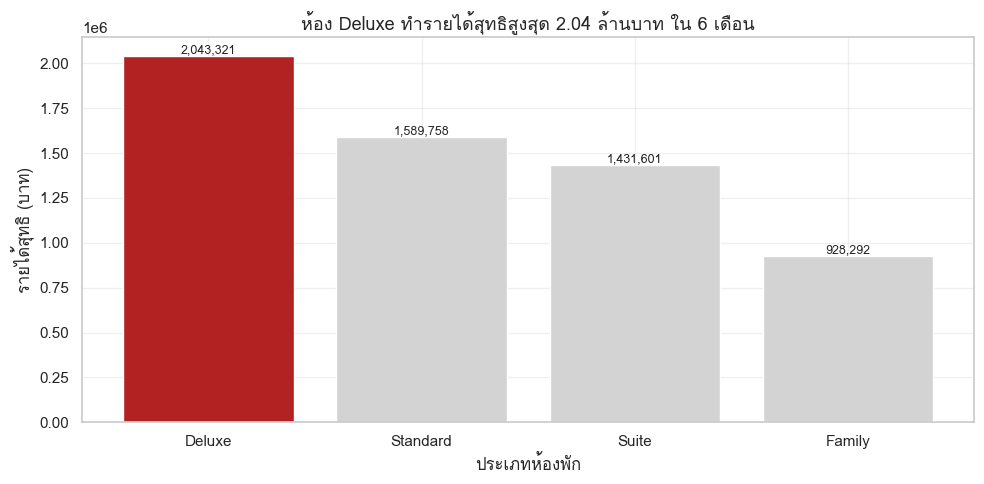

In [71]:
top_type = by_room_type.iloc[0]

# สีเน้นเฉพาะห้องที่ทำรายได้สูงสุด แท่งอื่นใช้สีเทา
colors = ["firebrick" if t == top_type["room_type"] else "lightgray"
          for t in by_room_type["room_type"]]

plt.figure(figsize=(10, 5))
bars = plt.bar(by_room_type["room_type"], by_room_type["net_revenue"], color=colors)

plt.title(f"ห้อง {top_type['room_type']} ทำรายได้สุทธิสูงสุด "
          f"{top_type['net_revenue']/1e6:.2f} ล้านบาท ใน 6 เดือน",
          fontsize=13, fontweight="bold")
plt.xlabel("ประเภทห้องพัก")
plt.ylabel("รายได้สุทธิ (บาท)")

for bar, v in zip(bars, by_room_type["net_revenue"]):
    plt.text(bar.get_x() + bar.get_width()/2, v, f"{v:,.0f}",
             ha="center", va="bottom", fontsize=9)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### กราฟที่ 2 : ยอดรวมกับยอดต่อคืนให้คำตอบคนละแบบ (Subplot)


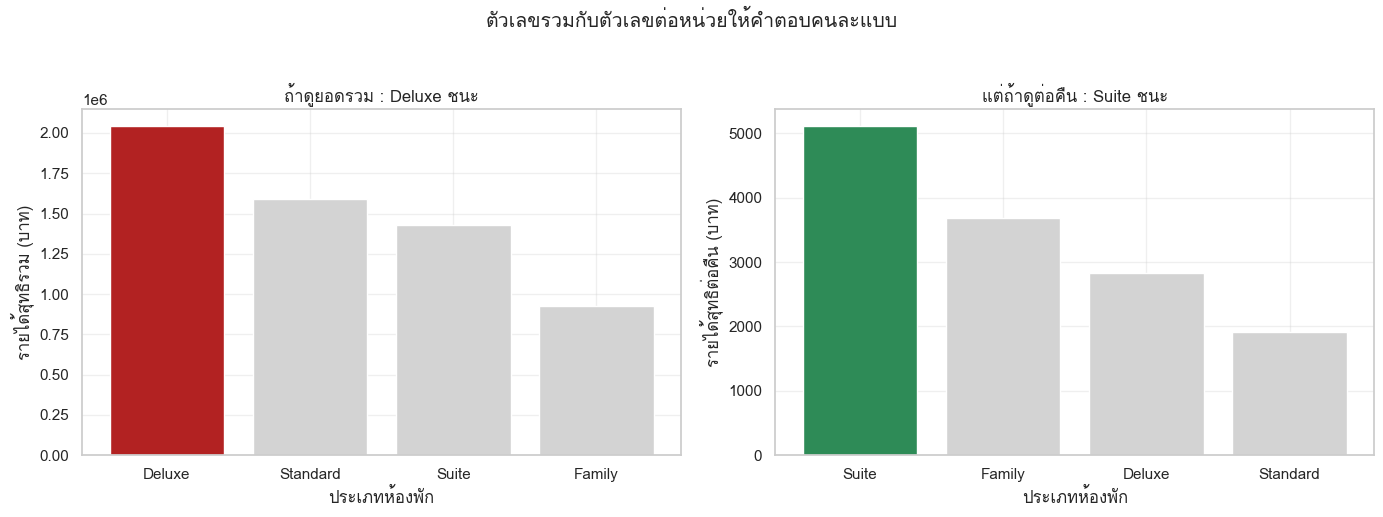

Deluxe ทำเงินรวมมากที่สุดเพราะมีห้องเยอะและจองบ่อย
แต่ Suite ทำเงินต่อคืนสูงกว่า 2.7 เท่า ของห้องที่ต่ำสุด


In [72]:
by_night = by_room_type.sort_values("net_per_night", ascending=False)
win_total = by_room_type.iloc[0]["room_type"]
win_night = by_night.iloc[0]["room_type"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ซ้าย: ยอดรวม
c1 = ["firebrick" if t == win_total else "lightgray" for t in by_room_type["room_type"]]
axes[0].bar(by_room_type["room_type"], by_room_type["net_revenue"], color=c1)
axes[0].set_title(f"ถ้าดูยอดรวม : {win_total} ชนะ", fontsize=12, fontweight="bold")
axes[0].set_xlabel("ประเภทห้องพัก")
axes[0].set_ylabel("รายได้สุทธิรวม (บาท)")

# ขวา: ยอดต่อคืน
c2 = ["seagreen" if t == win_night else "lightgray" for t in by_night["room_type"]]
axes[1].bar(by_night["room_type"], by_night["net_per_night"], color=c2)
axes[1].set_title(f"แต่ถ้าดูต่อคืน : {win_night} ชนะ", fontsize=12, fontweight="bold")
axes[1].set_xlabel("ประเภทห้องพัก")
axes[1].set_ylabel("รายได้สุทธิต่อคืน (บาท)")

plt.suptitle("ตัวเลขรวมกับตัวเลขต่อหน่วยให้คำตอบคนละแบบ", y=1.03,
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"{win_total} ทำเงินรวมมากที่สุดเพราะมีห้องเยอะและจองบ่อย")
print(f"แต่ {win_night} ทำเงินต่อคืนสูงกว่า "
      f"{by_night.iloc[0]['net_per_night'] / by_night.iloc[-1]['net_per_night']:.1f} เท่า"
      " ของห้องที่ต่ำสุด")

#### กราฟที่ 3 : ฤดูกาลดันราคาขึ้นได้จริงไหม (`pandas.plot()` + `secondary_y`)

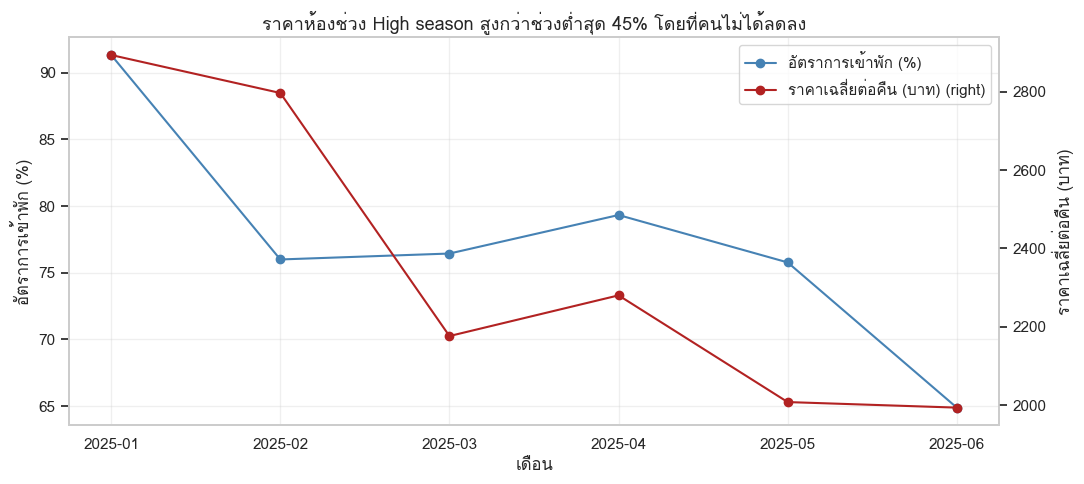

In [73]:
month_plot = by_month.set_index("booking_month")[["occupancy_%", "avg_rate"]]
month_plot.columns = ["อัตราการเข้าพัก (%)", "ราคาเฉลี่ยต่อคืน (บาท)"]

ax = month_plot.plot(figsize=(11, 5), marker="o", secondary_y="ราคาเฉลี่ยต่อคืน (บาท)",
                     color=["steelblue", "firebrick"])
gap = by_month["avg_rate"].max() / by_month["avg_rate"].min() - 1
ax.set_title(f"ราคาห้องช่วง High season สูงกว่าช่วงต่ำสุด {gap*100:.0f}% "
             "โดยที่คนไม่ได้ลดลง", fontsize=13, fontweight="bold")
ax.set_xlabel("เดือน")
ax.set_ylabel("อัตราการเข้าพัก (%)")
ax.right_ax.set_ylabel("ราคาเฉลี่ยต่อคืน (บาท)")
plt.tight_layout()
plt.show()

#### กราฟที่ 4 : ลูกค้าพักกี่คืน (Histogram + ทดลองปรับ `bins`)


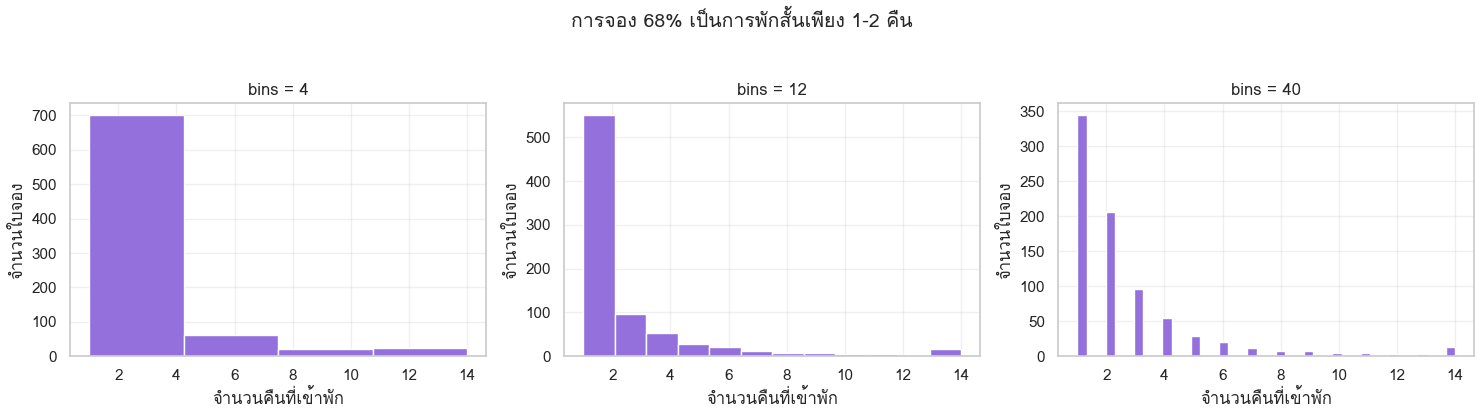

bins น้อยเกินไป (4) เห็นภาพรวมหยาบจนไม่รู้ว่าคนพัก 1 คืนหรือ 2 คืนมากกว่ากัน
bins มากเกินไป (40) เห็นแต่ช่องว่าง เพราะจำนวนคืนเป็นเลขจำนวนเต็ม
bins = 12 กำลังพอดีกับข้อมูลชุดนี้


In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n_bins in zip(axes, [4, 12, 40]):
    ax.hist(active["nights"], bins=n_bins, color="mediumpurple", edgecolor="white")
    ax.set_title(f"bins = {n_bins}")
    ax.set_xlabel("จำนวนคืนที่เข้าพัก")
    ax.set_ylabel("จำนวนใบจอง")

short = (active["nights"] <= 2).mean() * 100
plt.suptitle(f"การจอง {short:.0f}% เป็นการพักสั้นเพียง 1-2 คืน", y=1.04,
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("bins น้อยเกินไป (4) เห็นภาพรวมหยาบจนไม่รู้ว่าคนพัก 1 คืนหรือ 2 คืนมากกว่ากัน")
print("bins มากเกินไป (40) เห็นแต่ช่องว่าง เพราะจำนวนคืนเป็นเลขจำนวนเต็ม")
print("bins = 12 กำลังพอดีกับข้อมูลชุดนี้")

#### กราฟที่ 5 : ราคาต่อคืนกระจายตัวอย่างไรในแต่ละประเภทห้อง (`sns.boxplot()` + `hue`)


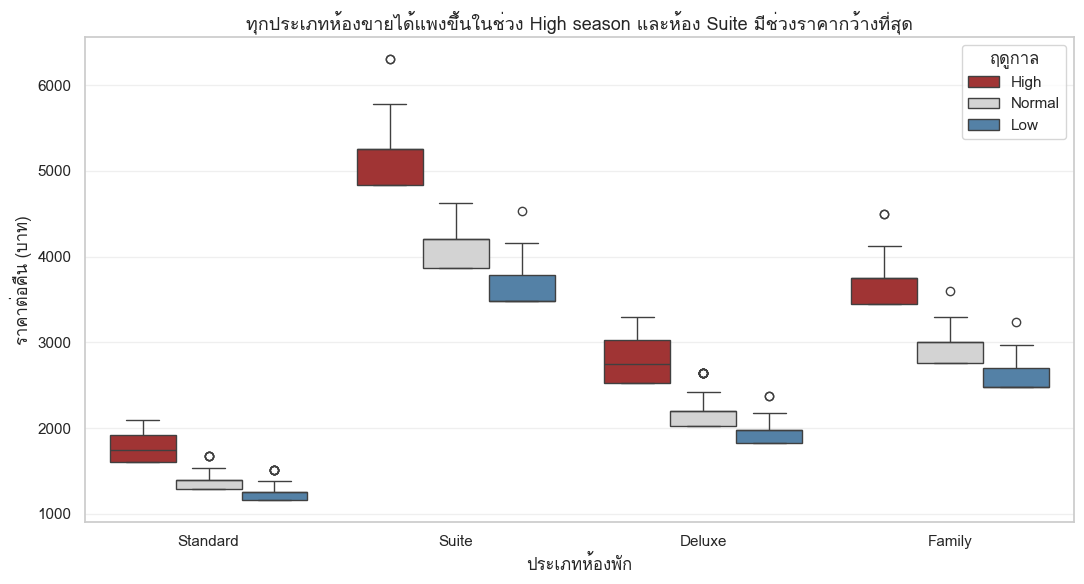

season        High      Low   Normal
room_type                           
Deluxe    2,750.00 1,980.00 2,200.00
Family    3,750.00 2,484.00 3,000.00
Standard  1,750.00 1,260.00 1,400.00
Suite     5,250.00 3,478.00 4,200.00


In [75]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=active, x="room_type", y="rate_per_night", hue="season",
            palette={"High": "firebrick", "Normal": "lightgray", "Low": "steelblue"})

plt.title("ทุกประเภทห้องขายได้แพงขึ้นในช่วง High season "
          "และห้อง Suite มีช่วงราคากว้างที่สุด", fontsize=13, fontweight="bold")
plt.xlabel("ประเภทห้องพัก")
plt.ylabel("ราคาต่อคืน (บาท)")
plt.legend(title="ฤดูกาล")
plt.tight_layout()
plt.show()

print(active.groupby(["room_type", "season"])["rate_per_night"]
      .median().unstack().round(0))

#### กราฟที่ 6 : ตัวแปรไหนสัมพันธ์กับยอดเงินบ้าง (`sns.heatmap()` + `.corr()`)

Correlation มีค่าระหว่าง -1 ถึง 1 — ใกล้ +1 คือไปทางเดียวกัน ใกล้ -1 คือตรงข้ามกัน

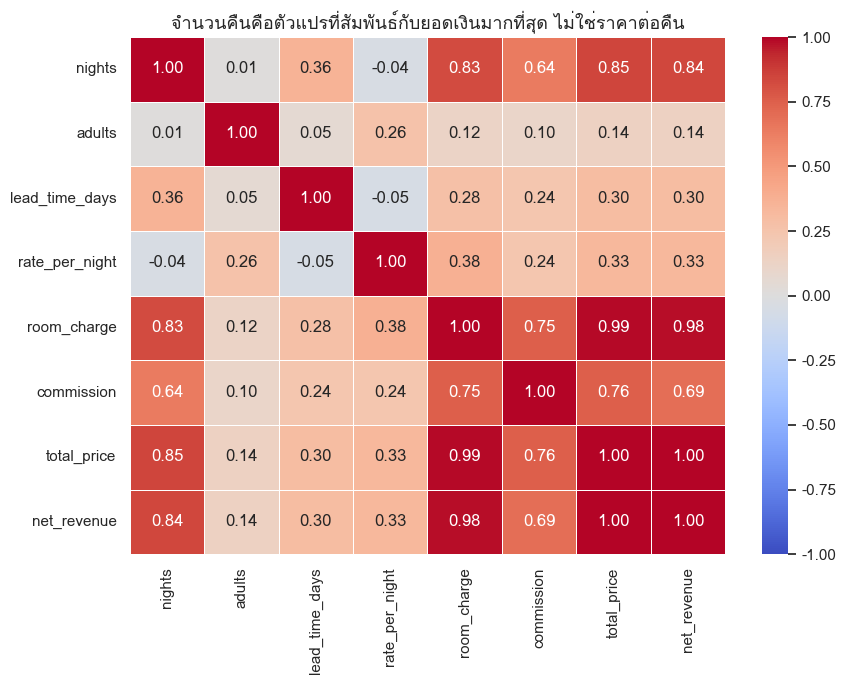

ค่า correlation กับ total_price เรียงจากมากไปน้อย
net_revenue      1.00
room_charge      0.99
nights           0.85
commission       0.76
rate_per_night   0.33
lead_time_days   0.30
adults           0.14
Name: total_price, dtype: float64

ข้อควรระวัง: correlation บอกแค่ความสัมพันธ์เชิงเส้น ไม่ได้แปลว่าเป็นเหตุเป็นผลกัน


In [76]:
numeric_cols = ["nights", "adults", "lead_time_days", "rate_per_night",
                "room_charge", "commission", "total_price", "net_revenue"]
corr = active[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title("จำนวนคืนคือตัวแปรที่สัมพันธ์กับยอดเงินมากที่สุด ไม่ใช่ราคาต่อคืน",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("ค่า correlation กับ total_price เรียงจากมากไปน้อย")
print(corr["total_price"].drop("total_price").sort_values(ascending=False).round(2))
print()
print("ข้อควรระวัง: correlation บอกแค่ความสัมพันธ์เชิงเส้น ไม่ได้แปลว่าเป็นเหตุเป็นผลกัน")

#### กราฟที่ 7 : ช่องทางไหนทำเงินได้จริง (Grouped Bar)

ยอดขายที่เห็นไม่ใช่เงินที่โรงแรมได้จริง เพราะ OTA หักค่าคอมมิชชัน 15%

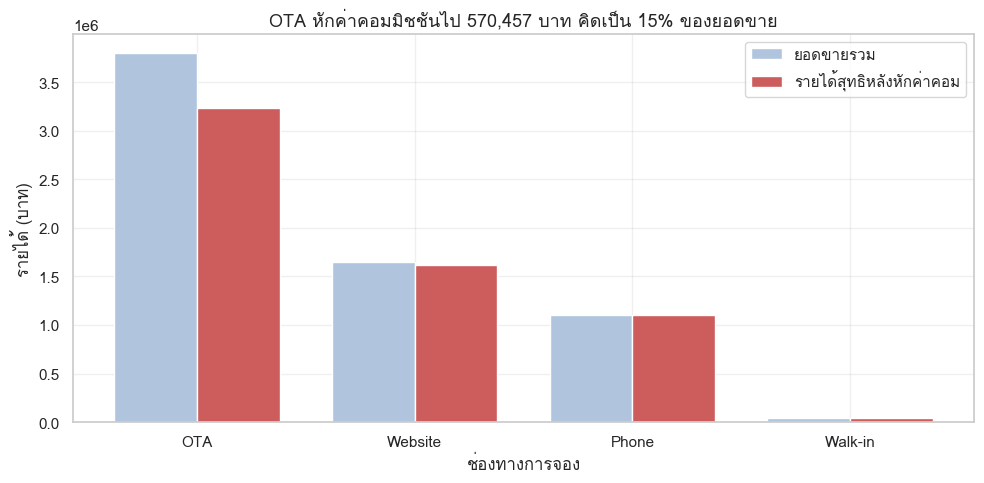

In [77]:
import numpy as np

ch = by_channel.sort_values("gross_revenue", ascending=False)
x = np.arange(len(ch))
w = 0.38
ota = ch[ch["channel"] == "OTA"].iloc[0]

plt.figure(figsize=(10, 5))
plt.bar(x - w/2, ch["gross_revenue"], w, label="ยอดขายรวม", color="lightsteelblue")
plt.bar(x + w/2, ch["net_revenue"], w, label="รายได้สุทธิหลังหักค่าคอม",
        color="indianred")

plt.xticks(x, ch["channel"])
plt.title(f"OTA หักค่าคอมมิชชันไป {ota['commission_paid']:,.0f} บาท "
          f"คิดเป็น {ota['commission_pct']:.0f}% ของยอดขาย",
          fontsize=13, fontweight="bold")
plt.xlabel("ช่องทางการจอง")
plt.ylabel("รายได้ (บาท)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### แดชบอร์ดสรุป : รวม 4 มุมมองไว้ในภาพเดียว (`plt.subplots(2, 2)`)

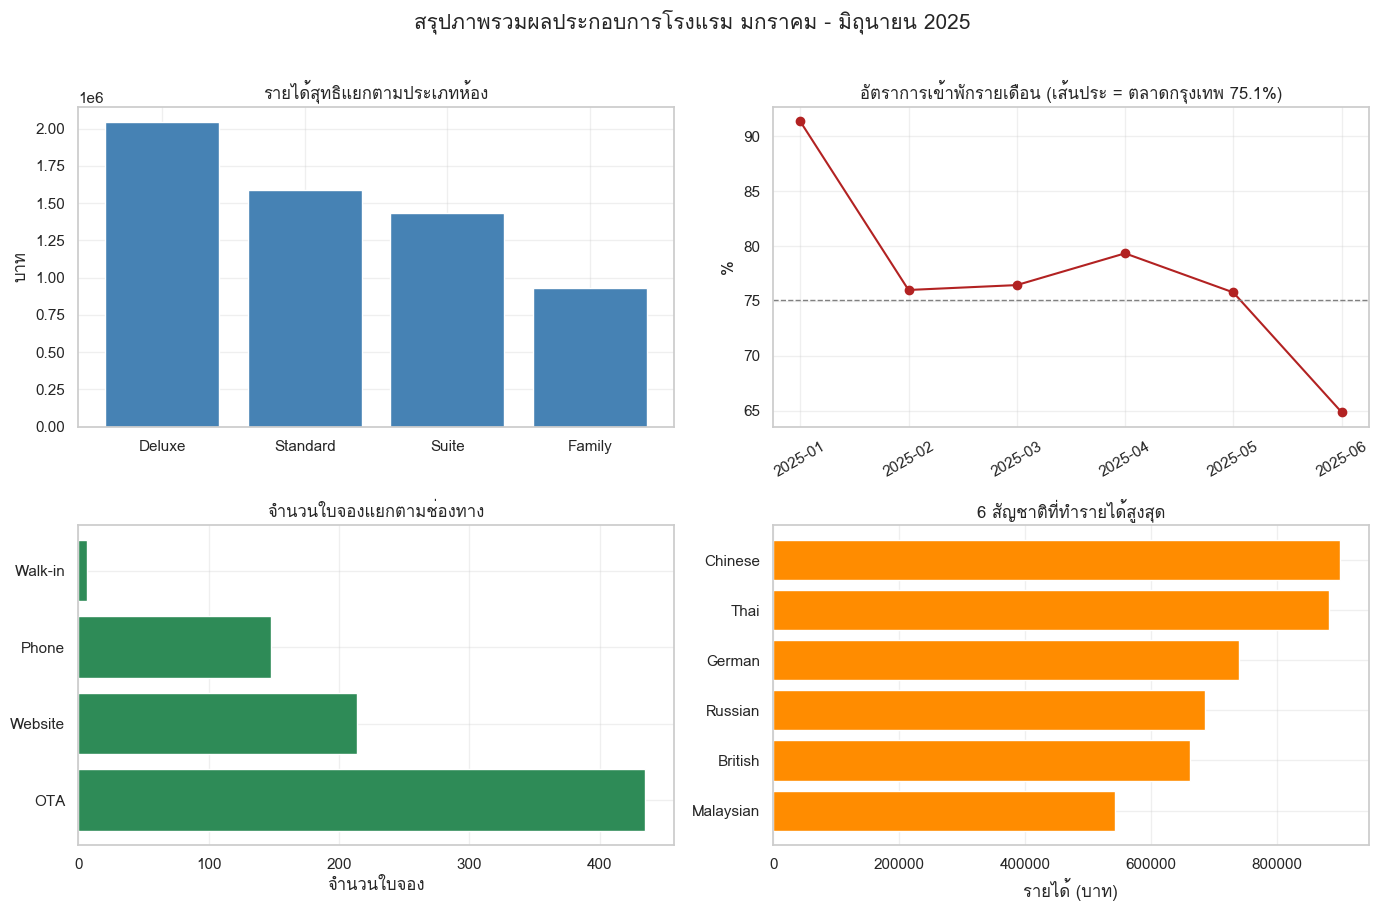

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (0,0) รายได้สุทธิแยกประเภทห้อง
axes[0, 0].bar(by_room_type["room_type"], by_room_type["net_revenue"],
               color="steelblue")
axes[0, 0].set_title("รายได้สุทธิแยกตามประเภทห้อง")
axes[0, 0].set_ylabel("บาท")

# (0,1) อัตราการเข้าพักรายเดือน
axes[0, 1].plot(by_month["booking_month"], by_month["occupancy_%"],
                marker="o", color="firebrick")
axes[0, 1].axhline(75.1, color="gray", linestyle="--", linewidth=1)
axes[0, 1].set_title("อัตราการเข้าพักรายเดือน (เส้นประ = ตลาดกรุงเทพ 75.1%)")
axes[0, 1].set_ylabel("%")
axes[0, 1].tick_params(axis="x", rotation=30)

# (1,0) สัดส่วนช่องทางการจอง
axes[1, 0].barh(ch["channel"], ch["bookings"], color="seagreen")
axes[1, 0].set_title("จำนวนใบจองแยกตามช่องทาง")
axes[1, 0].set_xlabel("จำนวนใบจอง")

# (1,1) 6 สัญชาติที่ทำรายได้สูงสุด
top_nat = by_nat.head(6).sort_values("revenue")
axes[1, 1].barh(top_nat["nationality"], top_nat["revenue"], color="darkorange")
axes[1, 1].set_title("6 สัญชาติที่ทำรายได้สูงสุด")
axes[1, 1].set_xlabel("รายได้ (บาท)")

plt.suptitle("สรุปภาพรวมผลประกอบการโรงแรม มกราคม - มิถุนายน 2025",
             y=1.01, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### ขั้นที่ 3 — Conclusion : สรุปเป็นข้อเสนอที่ทำได้จริง

การวิเคราะห์จะมีค่าก็ต่อเมื่อจบด้วย "แล้วเจ้าของโรงแรมควรทำอะไรต่อ"
ไม่ใช่จบแค่ "ตัวเลขเป็นแบบนี้"

In [79]:
print("=" * 62)
print("ข้อเสนอต่อผู้บริหารโรงแรม จากข้อมูล 6 เดือน")
print("=" * 62)
print(f"1. ห้อง {win_night} ให้รายได้ต่อคืนสูงสุด "
      f"({by_night.iloc[0]['net_per_night']:,.0f} บาท/คืน) "
      f"แต่มีเพียง {int(by_night.iloc[0]['total_nights'] / by_night.iloc[0]['avg_nights'])} "
      "ครั้งที่ขายได้")
print(f"   -> ควรพิจารณาเพิ่มห้องประเภทนี้ หรือปรับห้องที่ขายไม่ดีมาเป็นประเภทนี้")
print()
print(f"2. OTA จ่ายค่าคอมไป {ota['commission_paid']:,.0f} บาท ใน 6 เดือน")
print(f"   -> ถ้าดันลูกค้าเก่าเพียง 20% ให้จองผ่านเว็บไซต์เอง จะประหยัดได้ราว "
      f"{ota['commission_paid'] * 0.2:,.0f} บาท")
print()
print(f"3. ราคาช่วง High season สูงกว่าช่วงต่ำสุด {gap*100:.0f}% "
      "โดยที่จำนวนใบจองไม่ได้ลดลงตาม")
print("   -> ยังมีพื้นที่ปรับราคาขึ้นได้อีกในช่วงฤดูท่องเที่ยว")
print()
# จำนวนลูกค้าที่ถูกปฏิเสธเก็บอยู่ใน object hotel ซึ่งมีเฉพาะตอนรันโปรแกรมจำลอง
# ถ้าไฟล์นี้อ่านจาก CSV อย่างเดียว ให้รายงานมูลค่าที่เสียจากการยกเลิกแทน
try:
    print(f"4. มีลูกค้าถูกปฏิเสธเพราะห้องเต็ม {len(hotel.rejected_log):,} ราย")
    print("   -> คือรายได้ที่หลุดมือ ควรใช้เป็นข้อมูลตัดสินใจขยายห้อง")
except NameError:
    lost = bookings[bookings["status"] == "CANCELLED"]["total_price"].sum()
    print(f"4. ใบจองที่ถูกยกเลิกคิดเป็นมูลค่า {lost:,.0f} บาท")
    print("   -> ควรใช้นโยบายมัดจำกับการจองผ่าน OTA ที่ยกเลิกบ่อยที่สุด")
print("=" * 62)

ข้อเสนอต่อผู้บริหารโรงแรม จากข้อมูล 6 เดือน
1. ห้อง Suite ให้รายได้ต่อคืนสูงสุด (5,113 บาท/คืน) แต่มีเพียง 110 ครั้งที่ขายได้
   -> ควรพิจารณาเพิ่มห้องประเภทนี้ หรือปรับห้องที่ขายไม่ดีมาเป็นประเภทนี้

2. OTA จ่ายค่าคอมไป 570,457 บาท ใน 6 เดือน
   -> ถ้าดันลูกค้าเก่าเพียง 20% ให้จองผ่านเว็บไซต์เอง จะประหยัดได้ราว 114,091 บาท

3. ราคาช่วง High season สูงกว่าช่วงต่ำสุด 45% โดยที่จำนวนใบจองไม่ได้ลดลงตาม
   -> ยังมีพื้นที่ปรับราคาขึ้นได้อีกในช่วงฤดูท่องเที่ยว

4. มีลูกค้าถูกปฏิเสธเพราะห้องเต็ม 451 ราย
   -> คือรายได้ที่หลุดมือ ควรใช้เป็นข้อมูลตัดสินใจขยายห้อง


## ส่วนที่ 10 — สรุปผลเชิงธุรกิจ

In [80]:
best = by_room_type.iloc[0]
best_night = by_room_type.sort_values("net_per_night", ascending=False).iloc[0]
ota = by_channel[by_channel["channel"] == "OTA"].iloc[0]
high = by_season[by_season["season"] == "High"].iloc[0]
low = by_season[by_season["season"] == "Low"].iloc[0]

print(f"1) ห้องที่ทำรายได้สุทธิรวมสูงสุด : {best['room_type']} "
      f"({best['net_revenue']:,.0f} บาท จาก {best['total_bookings']} ใบจอง)")
print(f"2) ห้องที่ให้รายได้ต่อคืนสูงสุด  : {best_night['room_type']} "
      f"({best_night['net_per_night']:,.0f} บาท/คืน)")
print(f"3) ช่องทาง OTA ยอดขาย {ota['gross_revenue']:,.0f} บาท "
      f"ค่าคอมมิชชัน {ota['commission_paid']:,.0f} บาท ({ota['commission_pct']:.1f}%)")
print(f"4) ราคาเฉลี่ยต่อคืน High season {high['avg_rate']:,.0f} บาท "
      f"เทียบ Low season {low['avg_rate']:,.0f} บาท")
print(f"5) ถูกปฏิเสธเพราะห้องเต็ม {len(hotel.rejected_log):,} ราย")

1) ห้องที่ทำรายได้สุทธิรวมสูงสุด : Deluxe (2,043,321 บาท จาก 275 ใบจอง)
2) ห้องที่ให้รายได้ต่อคืนสูงสุด  : Suite (5,113 บาท/คืน)
3) ช่องทาง OTA ยอดขาย 3,803,047 บาท ค่าคอมมิชชัน 570,457 บาท (15.0%)
4) ราคาเฉลี่ยต่อคืน High season 2,846 บาท เทียบ Low season 2,001 บาท
5) ถูกปฏิเสธเพราะห้องเต็ม 451 ราย


### สรุปผล 5 ข้อ

1. **ห้อง Deluxe ทำรายได้สุทธิรวมสูงที่สุด** เนื่องจากเป็นจุดที่ราคาต่อคืนอยู่ในระดับสูง
   พอสมควรและยังมีปริมาณการจองมาก ต่างจากห้อง Suite ที่ราคาสูงกว่าแต่มีเพียง 2 ห้อง
   จึงมีเพดานปริมาณจำกัด

2. **เมื่อพิจารณารายได้สุทธิต่อคืน ห้อง Suite ให้ผลตอบแทนสูงที่สุด** หากโรงแรมจะลงทุน
   เพิ่มห้อง ควรพิจารณาห้อง Suite และ Family มากกว่าห้อง Standard ตัวเลขรวมและ
   ตัวเลขต่อหน่วยจึงให้ข้อสรุปที่ต่างกันและต้องดูควบคู่กัน

3. **ช่องทาง OTA นำลูกค้าเข้ามามากที่สุดแต่มีต้นทุนสูงที่สุด** ทั้งค่าคอมมิชชัน 15%
   และอัตราการยกเลิกที่สูงเป็นสองเท่าของการจองตรง ข้อเสนอเชิงกลยุทธ์คือส่งเสริมให้
   ลูกค้าเดิมกลับมาจองผ่านเว็บไซต์ของโรงแรม ซึ่งมีค่าธรรมเนียมเพียง 2%

4. **ฤดูกาลมีผลต่อราคาอย่างชัดเจนแต่ไม่ทำให้ปริมาณการจองลดลงมาก** ราคาเฉลี่ยต่อคืน
   ในช่วง High season สูงกว่า Low season ประมาณ 40% ขณะที่จำนวนใบจองใกล้เคียงกัน
   แสดงว่ายังมีโอกาสปรับราคาขึ้นได้อีกในช่วงฤดูท่องเที่ยว

5. **ตัวชี้วัดของข้อมูลจำลองสอดคล้องกับตลาดจริง** ทั้งอัตราการเข้าพัก ADR RevPAR
   ระยะเวลาพักเฉลี่ย และอัตราการยกเลิกแยกตามช่องทาง อยู่ในช่วงเดียวกับข้อมูลตลาด
   โรงแรมไทยปี 2025 ทำให้ข้อเสนอทั้ง 4 ข้อข้างต้นสามารถนำไปใช้อ้างอิงได้จริง